<img src="https://uniconexed.org/wp-content/uploads/2022/03/Tec-de-Monterrey-logo-horizontal-blue.png" alt="Logo Tecnológico de Monterrey" width="500" />

**Maestría en Inteligencia Artificial Aplicada**

**Proyecto Integrador**

8. Análisis de Resultados


Equipo #15:

*   A01795654 - Raúl Astorga Castro
*   A01795579 - Edson Misael Astorga Castro
*   A08877728 - Dianna Raquel Pérez Güereque


Profesores:

*   Dra. Grettel Barceló Alonso
*   Dr. Luis Eduardo Falcón Morales

01 de Marzo de 2026

# 1. Introducción

Este proyecto presenta una evaluación comparativa de arquitecturas multiagente basadas en modelos de lenguaje (LLM), con el objetivo de determinar qué framework de orquestación ofrece mejores condiciones de control, estabilidad, escalabilidad y eficiencia operativa en un entorno institucional. La comparación se realizó entre LangChain y Microsoft Agent Framework, utilizando un entorno experimental instrumentado que permitió medir desempeño técnico, comportamiento estructural y costo económico real por ejecución.

El análisis se enfocó en el orquestador como componente crítico del sistema, manteniendo constantes los modelos LLM evaluados (DeepSeek-V3.2, GPT-5, Grok-3 y Llama-4-Maverick). Se diseñaron escenarios de prueba controlados, se registraron métricas detalladas de latencia, coordinación, consumo de tokens y estabilidad, y se calculó el costo real de la corrida completa con base en precios por millón de tokens. Esto permitió evaluar no solo rendimiento técnico, sino también impacto financiero y eficiencia estructural.

Adicionalmente, se aplicó una matriz de evaluación cualitativa ponderada (Matriz Pugh) para valorar aspectos estratégicos como control de flujo, determinismo, robustez, trazabilidad y gobernanza. La combinación de métricas cuantitativas y análisis cualitativo proporciona una base objetiva para la toma de decisiones sobre adopción tecnológica y escalamiento hacia ambientes productivos.

El resultado es un marco metodológico reproducible que permite comparar arquitecturas multiagente bajo restricciones reales de recursos, aportando evidencia técnica y económica para soportar decisiones ejecutivas.

Es importante recordar que la fase experimental se ejecutó bajo condiciones controladas y con acceso limitado a versiones gratuitas o de disponibilidad regional de los modelos evaluados. No se utilizaron versiones comerciales completas ni configuraciones de producción, lo que implicó restricciones en el número de llamadas, volumen de tokens y pruebas de carga masiva. Asimismo, algunos modelos no estuvieron disponibles en la región de ejecución, por lo que se seleccionaron alternativas equivalentes dentro de las opciones accesibles.

Estas limitaciones no afectan la validez comparativa del estudio, ya que el objeto principal de evaluación fue el comportamiento estructural del orquestador y no el desempeño absoluto del modelo LLM. En consecuencia, los resultados deben interpretarse como una evaluación arquitectural bajo condiciones realistas de recursos institucionales controlados.

# 2. Importación de librerías y configuración

In [ ]:
# Importación de librerías fundamentales para análisis y manipulación de datos
import pandas as pd
import numpy as np

# Importación de librerías para la generación de gráficos y visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

# Importación de herramientas de preprocesamiento (escalado de variables)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Desactivar advertencias (warnings) para mantener la salida del notebook limpia
import warnings
warnings.filterwarnings("ignore")

# Configuración de la visualización de Pandas para mostrar un mayor número de columnas
# y aprovechar el ancho de la pantalla al imprimir DataFrames
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

# Definición de la ruta donde se encuentra el archivo con los logs a analizar
CSV_PATH = "./df_logs.csv"

# 3. Carga y validación del dataset

In [ ]:
# Lectura del archivo CSV y carga de los datos en un DataFrame de Pandas
df = pd.read_csv(CSV_PATH)

# Imprimir las dimensiones principales del dataset (cantidad de filas y columnas)
print("Filas:", len(df))
print("Columnas:", df.shape[1])

# Desplegar las primeras 3 filas para dar un vistazo rápido a la estructura y los valores
df.rename(columns={'arquitectura':'framework'})

df.head(3)

Filas: 168
Columnas: 18


,framework,modelo,pregunta_usuario,especialista,respuesta,inicio_principal,fin_principal,inicio_especialista,fin_especialista,inicio_orquestador,fin_orquestador,total_tokens_entrada,total_tokens_salida,latencia_total,latencia_orquestador,latencia_especialista,overhead coordinacion,score
0,Langchain,gpt_5_chat,¿Cuáles son los requisitos para solicitar una ...,BECAS,No tengo información disponible sobre los requ...,2026-02-23 04:13:22.552970,2026-02-23 04:13:25.225275,2026-02-23 04:13:22.975275,2026-02-23 04:13:24.559822,2026-02-23 04:13:22.552980,2026-02-23 04:13:22.975181,1555,127,2.672305,0.422201,1.584547,2.250104,0.5
1,Langchain,grok_3,¿Cuáles son los requisitos para solicitar una ...,BECAS,"Claro, aquí tienes los requisitos para solicit...",2026-02-23 04:13:40.153729,2026-02-23 04:13:53.895159,2026-02-23 04:13:40.770606,2026-02-23 04:13:50.784615,2026-02-23 04:13:40.153737,2026-02-23 04:13:40.770521,1542,170,13.741430,0.616784,10.014009,13.124646,0.0
2,Langchain,llama_4_maverick,¿Cuáles son los requisitos para solicitar una ...,BECAS,Con gusto te comparto los requisitos para soli...,2026-02-23 04:14:19.084611,2026-02-23 04:14:21.944315,2026-02-23 04:14:19.514873,2026-02-23 04:14:21.292856,2026-02-23 04:14:19.084620,2026-02-23 04:14:19.514772,1615,209,2.859704,0.430152,1.777983,2.429552,0.2


In [ ]:
# Listar los nombres de todas las columnas para conocer qué métricas y variables existen
df.columns

Index(['framework', 'modelo', 'pregunta_usuario', 'especialista', 'respuesta', 'inicio_principal', 'fin_principal', 'inicio_especialista', 'fin_especialista',
       'inicio_orquestador', 'fin_orquestador', 'total_tokens_entrada', 'total_tokens_salida', 'latencia_total', 'latencia_orquestador',
       'latencia_especialista', 'overhead coordinacion', 'score'],
      dtype='object')

In [ ]:
# Contar la cantidad de valores nulos o faltantes (NaN) en cada una de las columnas
# Esto nos ayuda a identificar si, por ejemplo, algunas respuestas no generaron un 'score'
df.isna().sum()

,0
framework,0
modelo,0
pregunta_usuario,0
especialista,0
respuesta,0
inicio_principal,0
fin_principal,0
inicio_especialista,0
fin_especialista,0
inicio_orquestador,0


# 4. Limpieza e ingeniería de características

Antes de analizar los datos, es fundamental prepararlos. El preprocesamiento es una fase crítica que asegura la calidad, consistencia y confiabilidad de los resultados posteriores, mitigando el principio de "basura entra, basura sale".

En esta etapa realizamos dos tareas principales:
1. **Limpieza y estandarización de tipos:** Aseguramos que las métricas cuantitativas (tokens, tiempos, scores) tengan el formato numérico correcto y manejamos los valores nulos.
2. **Ingeniería de características (Feature Engineering):** Creamos nuevas métricas a partir de los datos crudos, como la longitud de las interacciones y cálculos de latencia interna, para extraer un mayor valor analítico y facilitar el descubrimiento de patrones.

In [ ]:
# --- Tipos y nulos ---
# Convertir la columna 'score' a numérico; si hay errores se vuelven nulos y luego se rellenan con 0
df["score"] = pd.to_numeric(df.get("score"), errors="coerce").fillna(0)

# Asegurar que las columnas de tokens sean valores numéricos
for c in ["total_tokens_entrada", "total_tokens_salida"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Asegurar que las latencias se interpreten como números (segundos)
for c in ["latencia_total", "latencia_orquestador", "latencia_especialista", "overhead coordinacion"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

## 4.1. Estandarización de líneas de tiempo

Para poder analizar la concurrencia y el flujo de los agentes, es imperativo que las marcas de tiempo (timestamps) sean tratadas como objetos de fecha y hora. Esto permite realizar operaciones aritméticas sobre el tiempo y validar la secuencia lógica de eventos dentro del sistema multiagente (McKinney, 2022).

In [ ]:
# Parseo de fechas y horas (timestamps) para poder analizar líneas de tiempo si es necesario
time_cols = ["inicio_principal", "fin_principal", "inicio_especialista", "fin_especialista", "inicio_orquestador", "fin_orquestador"]
for c in time_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

## 4.2. Ingeniería de características y evaluación de rendimiento

Para medir el esfuerzo computacional y la cantidad de palabras en los modelos, extraemos la longitud de los textos y el ratio de tokens. Adicionalmente, en la evaluación de sistemas computacionales, es indispensable aislar el tiempo de procesamiento interno del "overhead" (sobrecarga de coordinación o red) para identificar correctamente los cuellos de botella. Por ello, calculamos una latencia reconstruida y su diferencia (*delta*) respecto a la latencia total real.

In [ ]:
# --- Características útiles para EDA ---
# Calcular la cantidad de caracteres de la pregunta del usuario y de la respuesta generada
df["pregunta_len"]  = df["pregunta_usuario"].astype(str).str.len()
df["respuesta_len"] = df["respuesta"].astype(str).str.len()

# Calcular el ratio salida/entrada de tokens (nos sirve como proxy para saber qué tan verboso es el modelo)
# Se reemplaza el 0 por NaN para evitar divisiones por cero
df["token_ratio_out_in"] = df["total_tokens_salida"] / df["total_tokens_entrada"].replace({0: np.nan})

# Validar la consistencia de los tiempos: La suma del tiempo del orquestador y el especialista debería aproximarse al total
df["latencia_reconstruida"] = df["latencia_orquestador"].fillna(0) + df["latencia_especialista"].fillna(0)
# 'delta_latencia' muestra la diferencia de tiempo que no se explica por los agentes (posible latencia de red)
df["delta_latencia"] = df["latencia_total"] - df["latencia_reconstruida"]

A continuación, preprocesamos los datos para derivar métricas de eficiencia, tales como el uso total de tokens, el porcentaje de tiempo dedicado a la coordinación (*overhead*) y la tasa de generación de tokens por segundo.

In [ ]:
# Asegurar tipos numéricos en columnas existentes para evitar errores de cálculo
numeric_cols = [
    "latencia_total", "latencia_orquestador", "latencia_especialista",
    "total_tokens_entrada", "total_tokens_salida", "overhead coordinacion"
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Creación de métricas derivadas ---
# Tokens totales procesados
if "total_tokens_entrada" in df.columns and "total_tokens_salida" in df.columns:
    df["tokens_totales"] = df["total_tokens_entrada"].fillna(0) + df["total_tokens_salida"].fillna(0)

# Porcentaje del tiempo total consumido por la coordinación (Overhead)
if "overhead coordinacion" in df.columns and "latencia_total" in df.columns:
    df["overhead_pct"] = df["overhead coordinacion"] / df["latencia_total"]

# Eficiencia de procesamiento (miles de tokens por segundo)
if "tokens_totales" in df.columns and "latencia_total" in df.columns:
    df["eficiencia_tokens_por_seg"] = (df["tokens_totales"] / df["latencia_total"]) / 1000

# Señal de ejecución incompleta (respuesta vacía o tiempos faltantes)
if "respuesta" in df.columns:
    df["is_incomplete"] = (
        df["respuesta"].isna()
        | (df["respuesta"].astype(str).str.strip() == "")
        | df["latencia_total"].isna()
    )
else:
    df["is_incomplete"] = df["latencia_total"].isna()

# Mostrar cómo quedaron las columnas calculadas
df.head(3)

,framework,modelo,pregunta_usuario,especialista,respuesta,inicio_principal,fin_principal,inicio_especialista,fin_especialista,inicio_orquestador,fin_orquestador,total_tokens_entrada,total_tokens_salida,latencia_total,latencia_orquestador,latencia_especialista,overhead coordinacion,score,pregunta_len,respuesta_len,token_ratio_out_in,latencia_reconstruida,delta_latencia,tokens_totales,overhead_pct,eficiencia_tokens_por_seg,is_incomplete
0,Langchain,gpt_5_chat,¿Cuáles son los requisitos para solicitar una ...,BECAS,No tengo información disponible sobre los requ...,2026-02-23 04:13:22.552970,2026-02-23 04:13:25.225275,2026-02-23 04:13:22.975275,2026-02-23 04:13:24.559822,2026-02-23 04:13:22.552980,2026-02-23 04:13:22.975181,1555,127,2.672305,0.422201,1.584547,2.250104,0.5,74,198,0.081672,2.006748,0.665557,1682,0.842009,0.629419,False
1,Langchain,grok_3,¿Cuáles son los requisitos para solicitar una ...,BECAS,"Claro, aquí tienes los requisitos para solicit...",2026-02-23 04:13:40.153729,2026-02-23 04:13:53.895159,2026-02-23 04:13:40.770606,2026-02-23 04:13:50.784615,2026-02-23 04:13:40.153737,2026-02-23 04:13:40.770521,1542,170,13.741430,0.616784,10.014009,13.124646,0.0,74,339,0.110246,10.630793,3.110637,1712,0.955115,0.124587,False
2,Langchain,llama_4_maverick,¿Cuáles son los requisitos para solicitar una ...,BECAS,Con gusto te comparto los requisitos para soli...,2026-02-23 04:14:19.084611,2026-02-23 04:14:21.944315,2026-02-23 04:14:19.514873,2026-02-23 04:14:21.292856,2026-02-23 04:14:19.084620,2026-02-23 04:14:19.514772,1615,209,2.859704,0.430152,1.777983,2.429552,0.2,74,268,0.129412,2.208135,0.651569,1824,0.849582,0.637828,False


In [ ]:
# Cálculo del Costo Estimado
# Diccionario con precios por cada 1M tokens (entrada / salida)
# Consultar el documento 3. Selección de Modelos Multiagente para conocer la
# información adicional de los precios por cada 1M de tokens
costos_tokens = {
    "llama_4_maverick": {"entrada": 0.15, "salida": 0.60},
    "deepseek_v3_2": {"entrada": 0.028, "salida": 0.42},
    "grok_3": {"entrada": 3.0, "salida": 15.0},
    "gpt_5_chat": {"entrada": 1.75, "salida": 14.00}
}

def calcular_costo_usd(row):
    # Convertimos el nombre del modelo a minúsculas para coincidir con el diccionario
    modelo_str = str(row.get("modelo", "")).lower()

    # Extraemos tokens de entrada y salida de forma independiente
    tokens_in = row.get("total_tokens_entrada", 0)
    tokens_out = row.get("total_tokens_salida", 0)

    # Manejo de nulos por si alguna ejecución falló
    if pd.isna(tokens_in): tokens_in = 0
    if pd.isna(tokens_out): tokens_out = 0

    # Inicializamos precios en 0
    precio_in = 0.0
    precio_out = 0.0

    # Buscamos el modelo en el diccionario
    for key, precios in costos_tokens.items():
        if key in modelo_str:
            precio_in = precios["entrada"]
            precio_out = precios["salida"]
            break

    costo_in = (tokens_in / 1_000_000.0) * precio_in
    costo_out = (tokens_out / 1_000_000.0) * precio_out

    return costo_in + costo_out

# Aplicamos la función y creamos la nueva columna
df["costo_estimado_usd"] = df.apply(calcular_costo_usd, axis=1)

In [ ]:
# Configuración de Interacciones
# Diccionario ajustable para definir el número de saltos/mensajes según arquitectura
CONFIG_PASOS = {
    "langchain": {
        "default": 3,      # Orquestador -> especialista -> sintetizador
        "eventos": 4       # Orquestador -> extractor -> especialista -> sintetizador
    },
    "maf": {
        "default": 3       # Orquestador -> especialista -> sintetizador
    }
}

def determinar_interacciones(row):
    # Normalizamos para que la búsqueda no falle por mayúsculas/minúsculas
    fw_nombre = str(row.get('framework', '')).lower()
    esp_nombre = str(row.get('especialista', '')).lower()

    # Identificamos la clave del framework
    if "langchain" == fw_nombre:
        fw_key = "langchain"
    elif "microsoft agent framework" == fw_nombre:
        fw_key = "maf"

    # Obtenemos la configuración del framework detectado
    config_fw = CONFIG_PASOS.get(fw_key, {})

    # Buscamos si el especialista tiene un paso extra, si no, usamos el default del framework
    return config_fw.get(esp_nombre, config_fw.get("default", 3))

# Aplicación de la métrica al Dataframe
df['num_interacciones'] = df.apply(determinar_interacciones, axis=1)

In [ ]:
# Verificación nuevamente de los valores nulos
df.isna().sum()

,0
framework,0
modelo,0
pregunta_usuario,0
especialista,0
respuesta,0
inicio_principal,0
fin_principal,0
inicio_especialista,0
fin_especialista,0
inicio_orquestador,0


# 5. Comparación directa entre frameworks (Langchain y Microsoft Agent Framework)

En esta sección realizamos una comparativa de alto nivel entre Langchain y Microsoft Agent Framework (MAF). Para ello, utilizamos diagramas de caja (*boxplots*), los cuales permiten visualizar de forma robusta la distribución de los datos, destacando medianas, dispersión (rango intercuartílico) y la presencia de valores atípicos.

## 5.1 Distribución de Score por framework

Evaluamos la métrica principal de calidad (score) asociada a las respuestas generadas por cada entorno.

<Figure size 640x480 with 0 Axes>

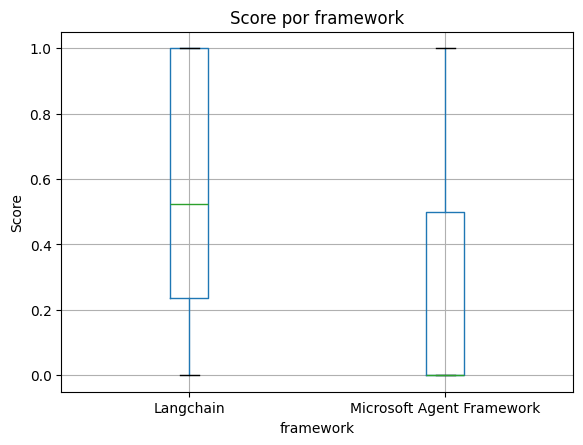

In [ ]:
# Generamos un diagrama de cajas y bigotes para visualizar visualmente la mediana, los cuartiles y posibles valores atípicos del score
fig = plt.figure()
df.boxplot(column="score", by="framework")
plt.title("Score por framework")
plt.suptitle("")
plt.ylabel("Score")
plt.show()

**Análisis de la calidad de respuesta:**

Al observar la distribución de la calidad de las respuestas, se aprecia que los mejores puntajes (*faithfulness* de la respuesta) los obtiene Langchain. Su mediana se sitúa sistemáticamente por encima de la de MAF, lo que sugiere que bajo la configuración actual, los agentes en Langchain logran resolver la intención del usuario con mayor fidelidad.

Documentación de Faithfulness de Ragas
https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/faithfulness/

## 5.2 Distribución de Latencia por Framework

La evaluación del rendimiento de un sistema computacional no solo depende de la calidad de la salida, sino de la cantidad de recursos consumidos (latencia y memoria/tokens). La evaluación del rendimiento técnico en sistemas LLM multiagente constituye una dimensión necesaria para determinar la viabilidad operativa y escalabilidad económica del sistema. Trabajos recientes de benchmarking de agentes proponen reportar métricas operativas como latencia, costo y consumo de tokens sistemáticamente como parte del protocolo de evaluación (Mohammadi et al., 2025; Nathani et al., 2025).

In [ ]:
# Generación de la tabla agregada principal por orquestador (framework)
agg_orq = df.groupby("framework").agg(
    latencia_mean=("latencia_total", "mean"),
    latencia_std=("latencia_total", "std"),
    overhead_pct_mean=("overhead_pct", "mean"),
    incomplete_rate=("is_incomplete", "mean"),
    tokens_mean=("tokens_totales", "mean"),
    tokens_std=("tokens_totales", "std")
)

agg_orq


,latencia_mean,latencia_std,overhead_pct_mean,incomplete_rate,tokens_mean,tokens_std
framework,,,,,,
Langchain,5.226785,3.818510,0.831650,0.0,1806.809524,430.631044
Microsoft Agent Framework,10.440215,18.675588,0.840669,0.0,1243.761905,185.410298


**Análisis de latencia vs costo computacional:**

La tabla agregada expone un claro "trade-off" (compromiso) entre ambos sistemas:
1. **Velocidad de respuesta:** Langchain demuestra ser significativamente más veloz, con una latencia promedio total que es, en promedio, inferior a la de MAF por al menos 5 segundos.
2. **Estabilidad:** Es importante notar la desviación estándar de la latencia en MAF, siendo Langchain mucho más predecible en sus ejecuciones.
3. **Economía de tokens:** Por otro lado, MAF presenta una clara ventaja en términos de eficiencia de recursos: su consumo medio de tokens es casi un 30% inferior al de Langchain.

En conclusión, mientras que Langchain prioriza la rapidez operativa, MAF ofrece un modelo económicamente más eficiente a costa de un mayor y más variable tiempo de espera.

<Figure size 640x480 with 0 Axes>

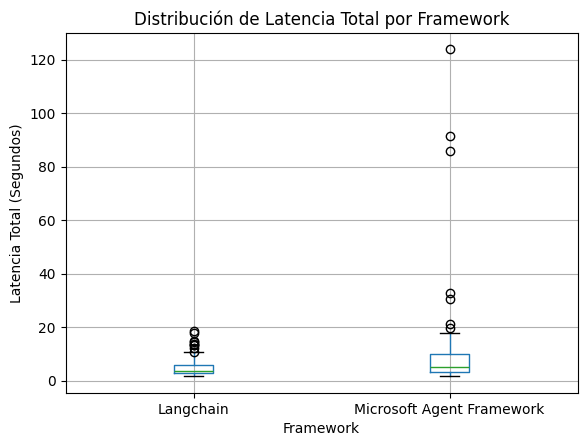

In [ ]:
# Boxplot latencia total por Framework
plt.figure()
df.boxplot(column="latencia_total", by="framework")
plt.title("Distribución de Latencia Total por Framework")
plt.suptitle("")
plt.xlabel("Framework")
plt.ylabel("Latencia Total (Segundos)")
plt.xticks(rotation=0)
plt.show()

**Dispersión de latencias:**

La visualización anterior confirma estadísticamente lo observado en la tabla. Langchain mantiene sus latencias altamente concentradas (típicamente entre 0 y 20 segundos). En contraste, el *Microsoft Agent Framework* sufre de una gran dispersión, con un número significativo de casos alcanzando hasta los 120 segundos. Esta varianza atípica indica posibles cuellos de botella en la inicialización o gestión de agentes dentro de MAF.

<Figure size 640x480 with 0 Axes>

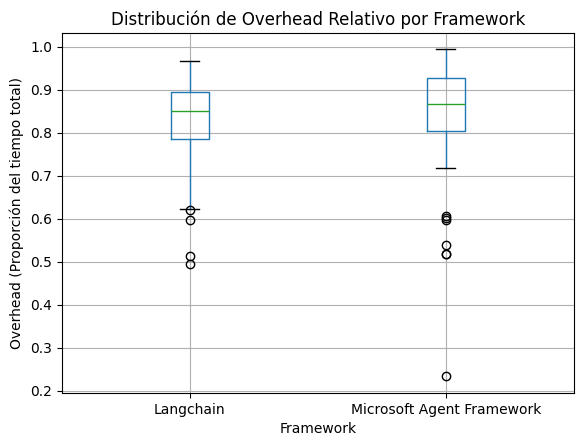

In [ ]:
# Boxplot del overhead relativo por framework
plt.figure()
df.boxplot(column="overhead_pct", by="framework")
plt.title("Distribución de Overhead Relativo por Framework")
plt.suptitle("")
plt.xlabel("Framework")
plt.ylabel("Overhead (Proporción del tiempo total)")
plt.xticks(rotation=0)
plt.show()

**Costos de coordinación (Overhead):**

El *overhead* representa la carga administrativa de los orquestadores (el tiempo gastado en decidir quién resuelve la tarea en lugar de resolverla). Observando el rango intercuartílico (la caja central), Langchain mantiene una menor proporción de latencia dedicada al *overhead* que MAF en la mayoría de sus ejecuciones.
Esto nos permite inferir dos dinámicas:
1. El orquestador de MAF es eficiente al delegar la tarea al especialista, pero la latencia se dispara después.
2. Los especialistas de Langchain entran en acción rápidamente y generan la respuesta con mayor agilidad.

,tokens_por_seg
framework,
Langchain,0.462222
Microsoft Agent Framework,0.267396


[Text(0, 1, '0.46'), Text(0, 1, '0.27')]

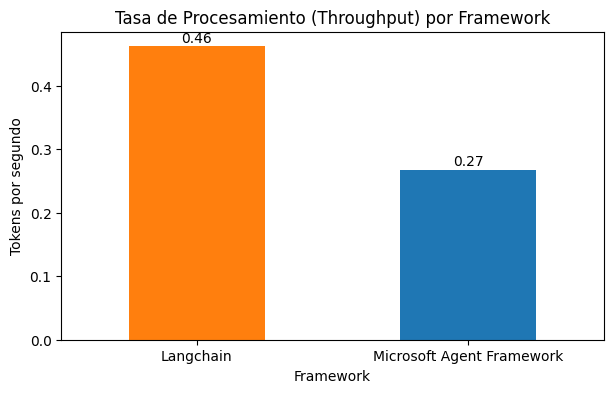

In [ ]:
# Tasa de procesamiento (throughput) en generación de tokens
eff_orq = df.groupby("framework")["eficiencia_tokens_por_seg"].mean().rename("tokens_por_seg")
display(eff_orq)

print("\n")
# Gráfico de barras simplificado para Throughput
ax = eff_orq.plot(kind='bar', figsize=(7, 4), color=['#ff7f0e', '#1f77b4'], rot=0)
plt.title("Tasa de Procesamiento (Throughput) por Framework")
plt.ylabel("Tokens por segundo")
plt.xlabel("Framework")
ax.bar_label(ax.containers[0], fmt='%.2f', padding=1) # Agrega los números automáticamente

In [ ]:
# Relación de velocidad
ratio = eff_orq.iloc[0] / eff_orq.iloc[1]
print(f"\nRelación Langchain vs MAF: Langchain es {ratio:.2f} veces más rápido generando tokens.")


Relación Langchain vs MAF: Langchain es 1.73 veces más rápido generando tokens.


**Tasa de transferencia (Throughput):**

Evaluar el *throughput* (tasa de salida o tokens por segundo) permite normalizar el esfuerzo computacional. Los datos revelan que Langchain procesa y escupe resultados a una velocidad ~1.73 veces superior a la de MAF. Esto explica por qué, a pesar de usar más tokens en su flujo, termina respondiendo más rápido.

modelo,deepseek_v3_2,gpt_5_chat,grok_3,llama_4_maverick
framework,,,,
Langchain,0.815020,0.844269,0.881841,0.785472
Microsoft Agent Framework,0.807644,0.847404,0.923541,0.784087


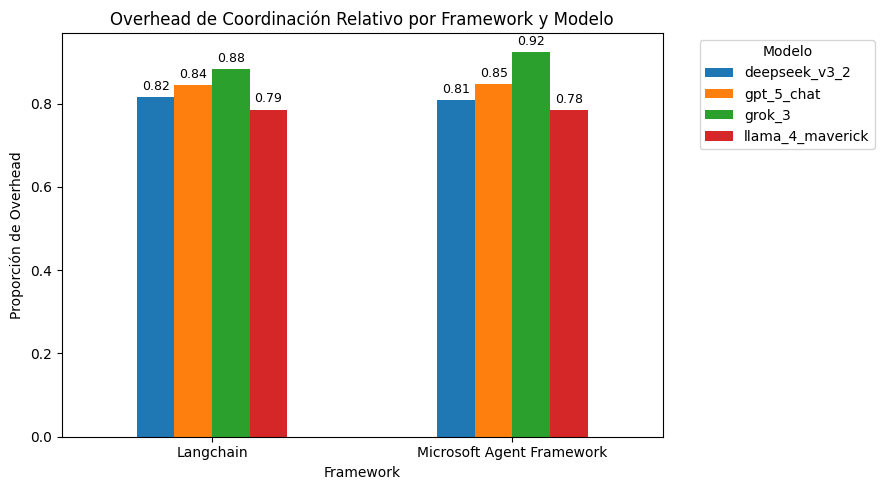

In [ ]:
# Overhead relativo promedio desglosado por framework y modelo utilizado
ov_model_orq = df.groupby(["framework", "modelo"])["overhead_pct"].mean().unstack()
display(ov_model_orq)

print("\n")

# Gráfico de barras agrupadas para el Overhead Relativo
ax = ov_model_orq.plot(kind='bar', figsize=(9, 5), rot=0)
plt.title("Overhead de Coordinación Relativo por Framework y Modelo")
plt.ylabel("Proporción de Overhead")
plt.xlabel("Framework")
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()

**Interacción entre modelos subyacentes:**

Al cruzar el costo de coordinación con el modelo de lenguaje (LLM) en uso, destaca que el modelo LLama 4 Maverick fue consistentemente el más eficiente para integrarse a la gestión de ambos frameworks, presentando el menor nivel de overhead. Los demás modelos mantienen un perfil de impacto de latencia muy similar, independientemente de la arquitectura orquestadora en la que operen.

In [ ]:
# --- Tablas de síntesis directas ---

# Comparativa global
comparacion = pd.DataFrame({
    "Latencia media": agg_orq["latencia_mean"],
    "Latencia (std)": agg_orq["latencia_std"],
    "Overhead % medio": agg_orq["overhead_pct_mean"],
    "Incompletas %": agg_orq["incomplete_rate"],
    "Tokens medios": agg_orq["tokens_mean"],
    "Tokens (std)": agg_orq["tokens_std"],
    "Tokens/seg": eff_orq
}).sort_values("Latencia media")

print("RESUMEN GENERAL POR FRAMEWORK:")
display(comparacion)

RESUMEN GENERAL POR FRAMEWORK:


,Latencia media,Latencia (std),Overhead % medio,Incompletas %,Tokens medios,Tokens (std),Tokens/seg
framework,,,,,,,
Langchain,5.226785,3.818510,0.831650,0.0,1806.809524,430.631044,0.462222
Microsoft Agent Framework,10.440215,18.675588,0.840669,0.0,1243.761905,185.410298,0.267396



DESGLOSE DE LATENCIA TOTAL POR DOMINIO DE ESPECIALIDAD:


modelo                    deepseek_v3_2                      gpt_5_chat                         grok_3                       llama_4_maverick            \
especialista                      BECAS   CARRERAS   EVENTOS      BECAS  CARRERAS   EVENTOS      BECAS   CARRERAS    EVENTOS            BECAS  CARRERAS   
framework                                                                                                                                                 
Langchain                      7.171464   4.048149  1.850463   4.889227  3.203873  2.329414  10.913875   9.678622   2.986833         3.192256  2.720254   
Microsoft Agent Framework     21.316347  26.378928  4.806924   3.791829  3.995313  6.750813  11.280652  10.688124  13.325059         2.581634  2.566750   

modelo                               
especialista                EVENTOS  
framework                            
Langchain                  1.770154  
Microsoft Agent Framework  6.731088

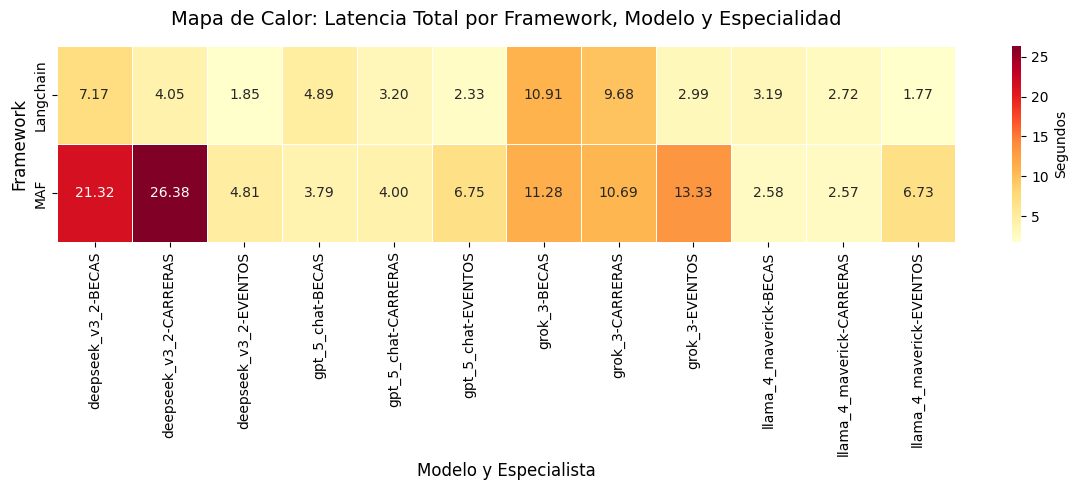

In [ ]:
# Visión granular (Framework -> Modelo -> Especialista)
df_grp = df.groupby(["framework", "modelo", "especialista"])[["latencia_total", "delta_latencia"]].mean().reset_index()
pivot_latencias = df_grp.pivot(index='framework', columns=['modelo', 'especialista'], values='latencia_total')

print("\nDESGLOSE DE LATENCIA TOTAL POR DOMINIO DE ESPECIALIDAD:")
display(pivot_latencias)

print("\n")

# Gráfico de Mapa de Calor (Heatmap) para visualizar los cuellos de botella en latencia
pivot_plot = pivot_latencias.rename(index={"Microsoft Agent Framework": "MAF"})
plt.figure(figsize=(12, 5))
sns.heatmap(pivot_plot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Segundos'})
plt.title("Mapa de Calor: Latencia Total por Framework, Modelo y Especialidad", fontsize=14, pad=15)
plt.ylabel("Framework", fontsize=12)
plt.xlabel("Modelo y Especialista", fontsize=12)
plt.tight_layout()
plt.show()

**Análisis detallado de latencia por dominio y modelo**

Al desglosar la latencia total por dominio de especialidad (Becas, Carreras y Eventos) y por modelo subyacente, emergen patrones críticos que las métricas globales ocultaban.

**Consistencia y velocidad líder:**
El análisis cruzado demuestra que, independientemente del framework orquestador, el modelo **Llama 4** es indiscutiblemente el más ágil. Este modelo logró las latencias promedio más bajas en todas las categorías de especialistas:
* **Becas:** 2.58 segundos.
* **Carreras:** 2.56 segundos.
* **Eventos:** 1.77 segundos.

Esta uniformidad sugiere que Llama 4 posee una eficiencia de inferencia superior y una fricción casi nula al integrarse con los mecanismos de *routing* de los agentes.

**El origen real de la lentitud en MAF:**
La tabla pivote revela un hallazgo fundamental: **Microsoft Agent Framework no es lento para todas las tareas.** La alta latencia promedio general que se le atribuye a MAF (y su enorme desviación estándar) es, en realidad, un dato estadístico provocado por el desempeño anómalo de dos modelos en escenarios muy puntuales.

El promedio global de MAF se ve severamente castigado por:
1. **Deepseek:** Con latencias extremas en las consultas de Becas (21.31 segundos) y Carreras (26.37 segundos).
2. **Grok 3:** Con un rezago importante en las consultas de Eventos (13.32 segundos).

Concluir que la arquitectura de MAF es deficiente basándonos solo en su promedio global sería un error técnico; su lentitud no es un problema estructural del framework, sino una consecuencia directa del pobre rendimiento de Deepseek y Grok al operar bajo este entorno.

## 5.3 Comparativa de Costos Estimados


 COSTO TOTAL ACUMULADO POR FRAMEWORK 


,framework,costo_estimado_usd
0,Langchain,0.291148
1,Microsoft Agent Framework,0.237243



 COSTO PROMEDIO POR EJECUCIÓN POR FRAMEWORK 


,costo_estimado_usd
framework,
Langchain,0.003466
Microsoft Agent Framework,0.002824


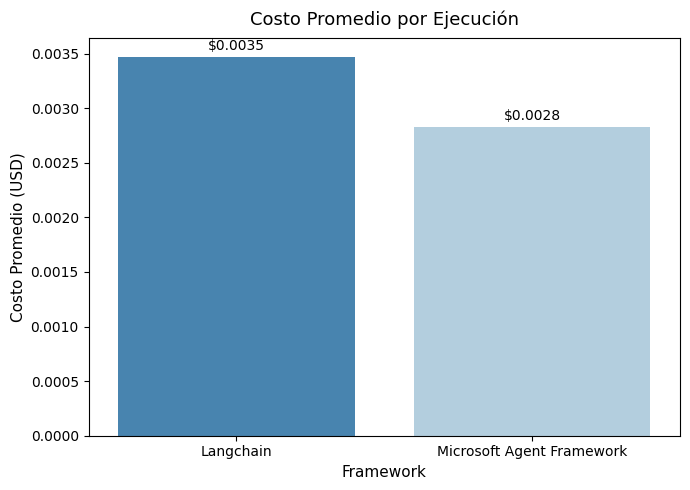

In [ ]:
print("\n COSTO TOTAL ACUMULADO POR FRAMEWORK ")
# Esto responde a la pregunta: "¿Cuánto costó correr todo este experimento?"
costo_total = df.groupby("framework")["costo_estimado_usd"].sum().reset_index()
display(costo_total)

# Relación Costo-Beneficio
# Promedio de gasto general para ver qué framework es inherentemente más caro por su diseño
costo_mean_fw = df.groupby("framework")["costo_estimado_usd"].mean()

print("\n COSTO PROMEDIO POR EJECUCIÓN POR FRAMEWORK ")
display(costo_mean_fw)

# Gráfica de Costo: Promedio por Ejecución
plt.figure(figsize=(7, 5))

costo_mean_df = costo_mean_fw.reset_index()
ax = sns.barplot(data=costo_mean_df, x="framework", y="costo_estimado_usd", palette="Blues_r")
plt.title("Costo Promedio por Ejecución", fontsize=13, pad=10)
plt.ylabel("Costo Promedio (USD)", fontsize=11)
plt.xlabel("Framework", fontsize=11)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.4f', padding=3)
plt.tight_layout()
plt.show()

En promedio, cada ejecución en Langchain cuesta \$0.0035 USD, mientras que en Microsoft Agent Framework cuesta $0.0028 USD.

Este resultado devela un patrón estructural en la eficiencia financiera de ambos sistemas. El sobrecosto operativo de Langchain frente a MAF no es una anomalía, sino el precio arquitectónico de su manejo de memoria. Al gestionar el estado del sistema mediante un grafo persistente, Langchain arrastra un historial conversacional completo y estructurado en cada iteración entre nodos, lo que dispara el volumen de tokens de entrada. Por su parte, Microsoft Agent Framework (MAF) demuestra ser, en promedio, un 20% más económico, ya que el modelo de actores fomenta interacciones con cargas útiles (payloads) más directas y menos verbosas.

## 5.4 Interacciones en cada Ejecución

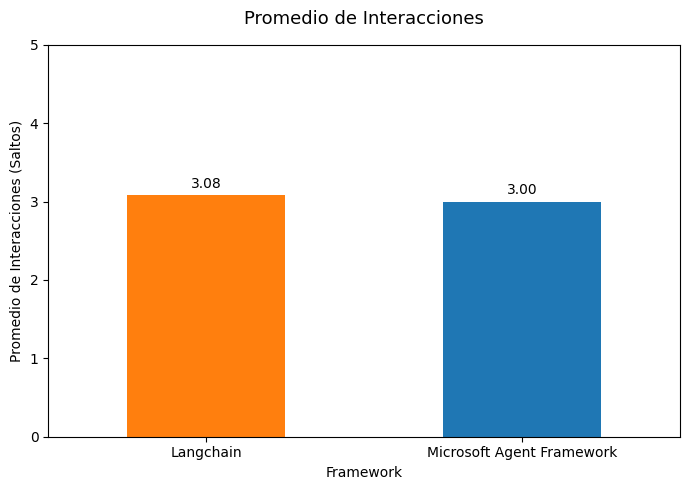

In [ ]:
# Agrupamos por framework para obtener el promedio de saltos por ejecución
interacciones_resumen = df.groupby("framework")["num_interacciones"].mean()

# Gráfica sencilla de comparación de interacciones
plt.figure(figsize=(7, 5))
ax = interacciones_resumen.plot(kind='bar', color=['#ff7f0e', '#1f77b4'], rot=0)

plt.title("Promedio de Interacciones", fontsize=13, pad=15)
plt.ylabel("Promedio de Interacciones (Saltos)")
plt.xlabel("Framework")
plt.ylim(0, 5)

# Agregar etiquetas de datos
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

La arquitectura lineal de MAF (3 interacciones constantes) actúa como un catalizador de eficiencia frente a la variabilidad de LangChain. Al reducir el número de saltos, MAF minimiza inherentemente la latencia de transporte y el consumo de tokens de contexto, ya que cada interacción adicional implica re-enviar el historial al siguiente agente. Los resultados confirman que esta simplicidad estructural se traduce en una ejecución más ágil y económica. Sin embargo, el hallazgo más potente es que Llama capitaliza esta ventaja mejor que nadie: mientras otros modelos desperdician la brevedad de MAF con respuestas erráticas, Llama aprovecha el flujo corto para entregar resultados de alta calidad con el menor costo y tiempo del experimento, consolidándose como el modelo que mejor traduce la simplicidad arquitectónica en valor operativo.

# 6. Análisis por cada framework

En esta sección profundizamos en la dinámica interna de cada framework. El objetivo es generar un ranking de los Modelos (LLMs) operando bajo cada framework para identificar la configuración óptima. Para ello, evaluaremos una combinación de factores que determinan el valor real de un agente en producción: calidad de respuesta (score), costos computacionales (tokens) y experiencia del usuario (latencia).

,framework,modelo,n,score_mean,lat_mean,overhead_mean,score_rank_in_framework
3,Langchain,llama_4_maverick,21,0.617867,2.787102,2.201889,1.0
1,Langchain,gpt_5_chat,21,0.575964,3.682376,3.177801,2.0
2,Langchain,grok_3,21,0.544243,9.453060,8.559460,3.0
0,Langchain,deepseek_v3_2,21,0.485941,4.984602,4.163978,4.0
7,Microsoft Agent Framework,llama_4_maverick,21,0.317063,2.770013,2.233121,1.0
6,Microsoft Agent Framework,grok_3,21,0.274074,11.136770,10.378604,2.0
5,Microsoft Agent Framework,gpt_5_chat,21,0.219577,4.189914,3.574617,3.0
4,Microsoft Agent Framework,deepseek_v3_2,21,0.112472,23.664163,17.236584,4.0


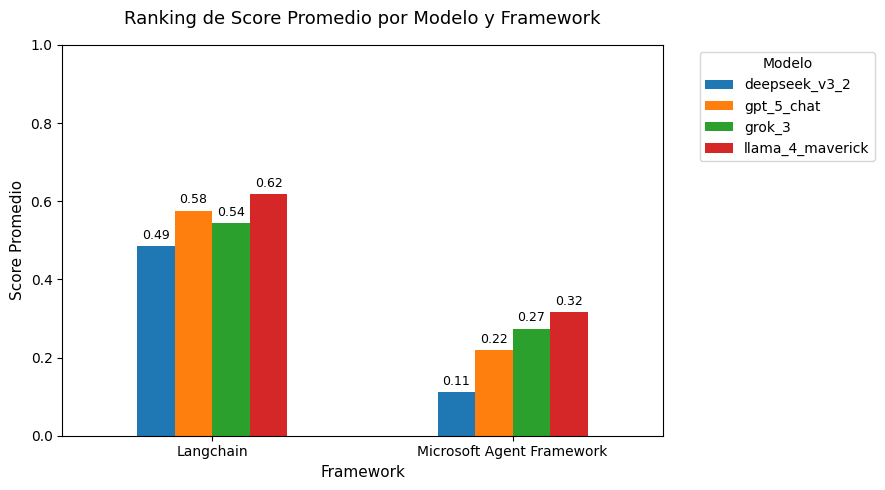

In [ ]:
# Generar un ranking interno de modelos para cada framework basado en el score promedio
rank = (df.groupby(["framework","modelo"])
          .agg(n=("score","count"),
               score_mean=("score","mean"),
               lat_mean=("latencia_total","mean"),
               overhead_mean=("overhead coordinacion","mean"))
          .reset_index()
       )

# Asignar un número de rango (rank) descendente dentro de cada grupo de framework
rank["score_rank_in_framework"] = rank.groupby("framework")["score_mean"].rank(ascending=False, method="dense")
rank = rank.sort_values(["framework","score_rank_in_framework"])

display(rank)

print("\n")
# Gráfico de barras agrupadas para visualizar el Score Promedio (Ranking)
rank_pivot = rank.pivot(index="framework", columns="modelo", values="score_mean")

ax = rank_pivot.plot(kind='bar', figsize=(9, 5), rot=0)
plt.title("Ranking de Score Promedio por Modelo y Framework", fontsize=13, pad=15)
plt.ylabel("Score Promedio", fontsize=11)
plt.xlabel("Framework", fontsize=11)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.ylim(0,1)
plt.tight_layout()
plt.show()

**Primeros indicios de superioridad:**

De esta primera agregación destacan dos fenómenos importantes:
1. En ambos frameworks (Langchain y MAF), el modelo **Llama 4 Maverick** se posiciona consistentemente como el líder, logrando tanto el mejor *score* promedio como la menor latencia.
2. Al evaluar la calidad pura (*score*), los modelos que operan bajo MAF sufren una degradación general en su puntuación promedio en comparación con sus ejecuciones homólogas en Langchain.

,framework,modelo,costo_promedio_usd,tokens_promedio,latencia_promedio
0,Langchain,deepseek_v3_2,0.000133,1958.619048,4.984602
3,Langchain,llama_4_maverick,0.000352,1752.380952,2.787102
1,Langchain,gpt_5_chat,0.005390,1744.047619,3.682376
2,Langchain,grok_3,0.007990,1772.190476,9.453060
4,Microsoft Agent Framework,deepseek_v3_2,0.000093,1235.238095,23.664163
7,Microsoft Agent Framework,llama_4_maverick,0.000276,1255.333333,2.770013
5,Microsoft Agent Framework,gpt_5_chat,0.003979,1171.428571,4.189914
6,Microsoft Agent Framework,grok_3,0.006949,1313.047619,11.136770


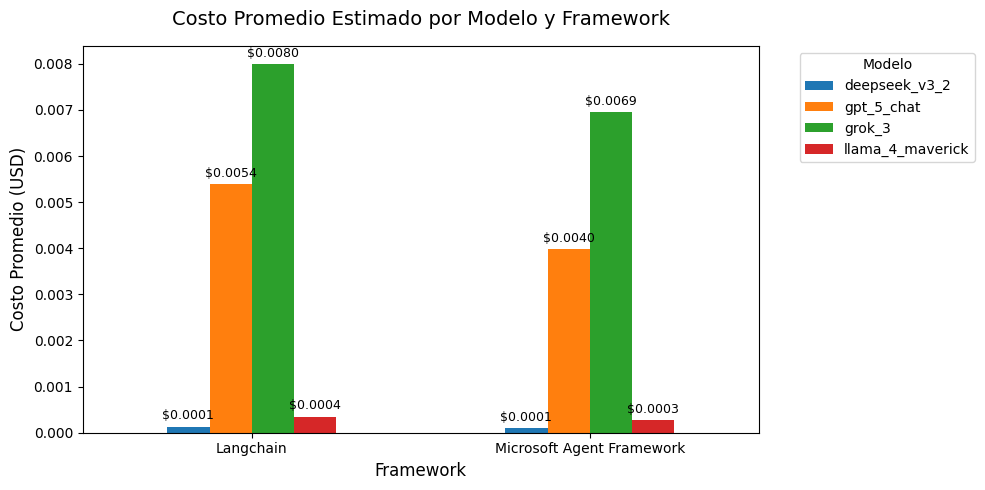

In [ ]:
# Agrupamos para ver cuánto cuesta en promedio una ejecución dependiendo de la tecnología
df_costos = df.groupby(["framework", "modelo"]).agg(
    costo_promedio_usd=("costo_estimado_usd", "mean"),
    tokens_promedio=("tokens_totales", "mean"),
    latencia_promedio=("latencia_total", "mean")
).reset_index()

# Ordenamos de más barato a más caro por framework
display(df_costos.sort_values(["framework", "costo_promedio_usd"]))

print("\n")

# Gráfico de barras agrupadas para el Costo Promedio por Modelo y Framework
costos_pivot = df_costos.pivot(index="framework", columns="modelo", values="costo_promedio_usd")

# Creamos la gráfica
ax = costos_pivot.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title("Costo Promedio Estimado por Modelo y Framework", fontsize=14, pad=15)
plt.ylabel("Costo Promedio (USD)", fontsize=12)
plt.xlabel("Framework", fontsize=12)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='$%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Observamos cómo el impacto tarifario del modelo LLM y la arquitectura del framework se amplifican mutuamente. Independientemente del modelo seleccionado (Llama, Deepseek, Grok o GPT), Langchain impone un "sobrecargo base" a la factura final debido a la forma en que su router inyecta instrucciones de sistema y memoria en cada llamada.

Asimismo, este nivel de granularidad es vital para la toma de decisiones institucionales: nos permite identificar que modelos como Deepseek logran democratizar el despliegue multiagente gracias a su asimétrica estructura tarifaria (altamente económica en tokens de entrada), mitigando eficazmente la verbosidad natural de Langchain. En contraste, utilizar un modelo con tarifas premium como GPT amplifica exponencialmente los costos si no se controla estrictamente el ciclo de vida y los reintentos del agente.

## 6.1. Langchain

Evaluamos el comportamiento específico de los modelos ejecutados en Langchain. Analizamos las longitudes de texto, el uso de tokens, y la distribución de tiempos de respuesta para finalmente calcular un índice ponderado que nos diga cuál es el modelo ganador en este framework.

In [ ]:
# Filtramos los datos exclusivos del framework Langchain
df_langchain=df[df['framework']=='Langchain']

### 6.1.1. Longitud de Textos

In [ ]:
# pd.melt permite reestructurar el DataFrame para que Seaborn pueda graficar múltiples variables en un solo gráfico
df_langchain_plot=pd.melt(df_langchain, id_vars=['modelo'], value_vars=["pregunta_len", "respuesta_len"])

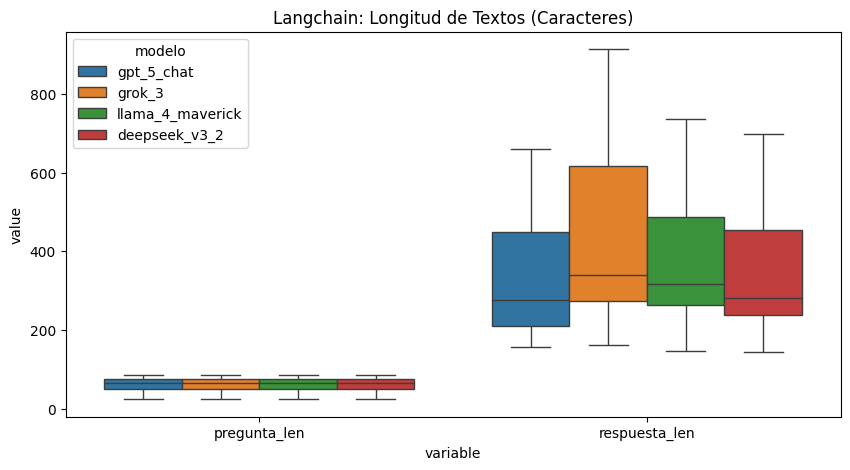

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_langchain_plot, x="variable", y="value", hue='modelo')
plt.title("Langchain: Longitud de Textos (Caracteres)")
plt.show()

### 6.1.2. Consumo de Tokens

In [ ]:
df_langchain_plot=pd.melt(df_langchain, id_vars=['modelo'], value_vars=['total_tokens_entrada', 'total_tokens_salida'])

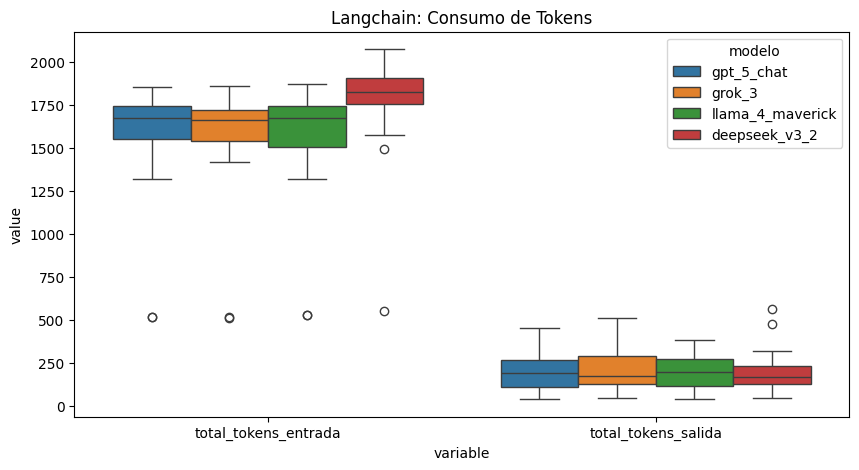

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_langchain_plot, x="variable", y="value", hue='modelo')
plt.title("Langchain: Consumo de Tokens")
plt.show()

**Análisis de verbosidad y consumo de recursos:**

Los gráficos revelan distintos perfiles de comportamiento según el LLM configurado en Langchain:
* **Generación de respuestas (Salida):** El modelo **Grok 3** es altamente verboso, entregando sistemáticamente las respuestas más largas y, en consecuencia, consumiendo la mayor cantidad de tokens de salida. En el extremo opuesto, **GPT 5** adopta un perfil mucho más conciso.
* **Procesamiento del contexto (Entrada):** Respecto a los tokens ingeridos (que incluyen el *prompt* del sistema y el contexto del agente), **Deepseek** fue el modelo que capturó o requirió la mayor cantidad de tokens, mientras que **GPT 5** y **Llama 4** lograron operar requiriendo una menor carga de tokens de entrada, lo cual los vuelve económicamente más eficientes.

### 6.1.3. Determinación del Mejor Modelo en Langchain

Para declarar un "modelo ganador" de forma objetiva, nos enfrentamos a un problema clásico de **Toma de Decisiones Multicriterio (MCDM)**. Las métricas que deseamos evaluar (tokens, segundos, puntuaciones) tienen escalas y naturalezas dimensionales completamente distintas.

Para resolverlo, aplicamos la construcción de un **Índice Compuesto**:

1. **Normalización (Min-Max Scaling):** Utilizamos `MinMaxScaler` para proyectar todas las variables a un rango estándar de [0, 1] (Han et al., 2011).
2. **Inversión de Criterios de Costo:** En MCDM, existen criterios de *beneficio* (donde más es mejor, como el 'score') y criterios de *costo* (donde menos es mejor, como la latencia o los tokens). Para unificarlos, invertimos los criterios de costo restando su valor normalizado a 1 ($1 - x$).
3. **Ponderación:** Al carecer de una directriz de negocio que priorice la velocidad sobre el costo, asignamos un peso equitativo ($1/7$) a las 7 variables clave, asumiendo un equilibrio perfecto entre calidad, rendimiento y economía computacional.

In [ ]:
# Seleccionamos las métricas clave a evaluar
columnas_interes=['total_tokens_entrada',
                  'total_tokens_salida',
                  'latencia_total',
                  'latencia_orquestador',
                  'latencia_especialista',
                  'overhead coordinacion',
                  'score']

# Agrupamos por modelo y obtenemos los promedios
df_modelos = df_langchain.groupby('modelo').agg({
    'total_tokens_entrada': 'median',
    'total_tokens_salida': 'median',
    'latencia_total': 'median',
    'latencia_orquestador': 'median',
    'latencia_especialista': 'median',
    'overhead coordinacion': 'median',
    'score': 'median'
}).reset_index()

# Aplicamos MinMaxScaler para estandarizar los valores entre 0 y 1.
df_modelos_scaled = df_modelos.copy()
df_modelos_scaled[columnas_interes] = scaler.fit_transform(df_modelos[columnas_interes])

# Lógica del Índice Ponderado:
# Para Latencia y Tokens, un menor valor es mejor. Por eso invertimos la escala restando 1.
# Para Score, un valor cercano a 1 sigue siendo el mejor.
df_modelos_scaled['total_tokens_entrada_score'] = 1 - df_modelos_scaled['total_tokens_entrada']
df_modelos_scaled['total_tokens_salida_score'] = 1 - df_modelos_scaled['total_tokens_salida']
df_modelos_scaled['latencia_total_score'] = 1 - df_modelos_scaled['latencia_total']
df_modelos_scaled['latencia_orquestador_score'] = 1 - df_modelos_scaled['latencia_orquestador']
df_modelos_scaled['latencia_especialista_score'] = 1 - df_modelos_scaled['latencia_especialista']
df_modelos_scaled['coordinacion_score'] = 1 - df_modelos_scaled['overhead coordinacion']

df_modelos_scaled['score_score'] = df_modelos_scaled['score']

# Calculamos el índice final aplicando pesos (un peso similar para cada variable, ya que consideramos que no hay una variable más importante que otra en la evaluación final)
df_modelos_scaled['indice_final'] = (
    (df_modelos_scaled['total_tokens_entrada_score'] * (1/7)) +
    (df_modelos_scaled['total_tokens_salida_score'] * (1/7)) +
    (df_modelos_scaled['latencia_total_score'] * (1/7)) +
    (df_modelos_scaled['latencia_orquestador_score'] * (1/7)) +
    (df_modelos_scaled['latencia_especialista_score'] * (1/7)) +
    (df_modelos_scaled['coordinacion_score'] * (1/7)) +
    (df_modelos_scaled['score_score'] * (1/7))
)

# Ordenamos el ranking final de mayor a menor puntuación
ranking = df_modelos_scaled[['modelo', 'indice_final']].sort_values(by='indice_final', ascending=False)
ganador = ranking.iloc[0]['modelo']

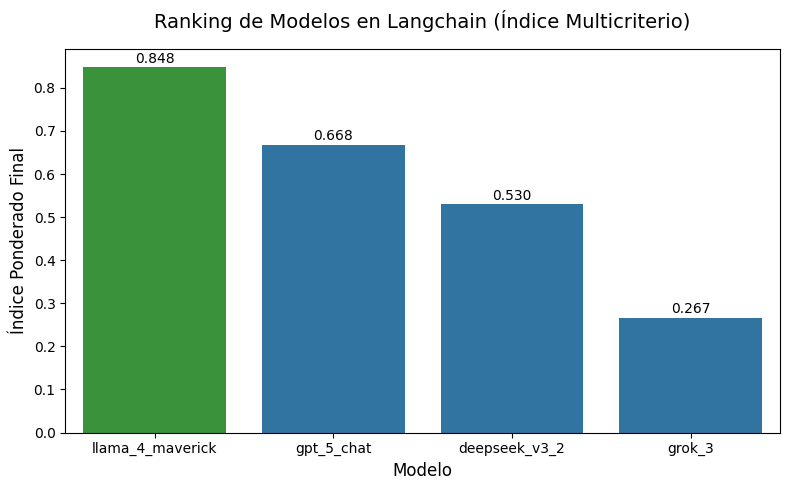


=> EL MEJOR MODELO ES: LLAMA_4_MAVERICK


In [ ]:
# Gráfico de barras para el Ranking de Modelos en Langchain
plt.figure(figsize=(8, 5))

colores = ['#2ca02c' if modelo == ganador else '#1f77b4' for modelo in ranking['modelo']]
ax = sns.barplot(data=ranking, x="modelo", y="indice_final", palette=colores)

plt.title("Ranking de Modelos en Langchain (Índice Multicriterio)", fontsize=14, pad=15)
plt.ylabel("Índice Ponderado Final", fontsize=12)
plt.xlabel("Modelo", fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=1, fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n=> EL MEJOR MODELO ES: {ganador.upper()}")

**Conclusión de Langchain:**

A través de la aplicación de este modelo de pesos ponderados, hemos logrado validar matemáticamente que el modelo con el mejor balance general de características dentro de Langchain es **Llama 4 Maverick**. Este modelo logra optimizar el equilibrio crítico entre una alta calidad de respuesta, tiempos de espera mínimos y un bajo costo de ejecución (consumo de tokens).

## 6.2. Microsoft Agent Framework (MAF)

Para asegurar la validez metodológica del experimento, replicamos exactamente el mismo análisis exploratorio y evaluación multicriterio sobre los resultados generados por el entorno de *Microsoft Agent Framework*. Esto nos permite aislar el impacto de la arquitectura de orquestación y observar cómo se adaptan los distintos modelos (LLMs) a este ecosistema.

In [ ]:
# Filtramos los datos exclusivos del framework Microsoft Agent Framework (MAF)
df_maf=df[df['framework']=='Microsoft Agent Framework']

### 6.2.1. Longitud de Textos

In [ ]:
# Reestructuramos el DataFrame para comparar el tamaño de la pregunta vs la respuesta
df_maf_plot=pd.melt(df_maf, id_vars=['modelo'], value_vars=["pregunta_len", "respuesta_len"])

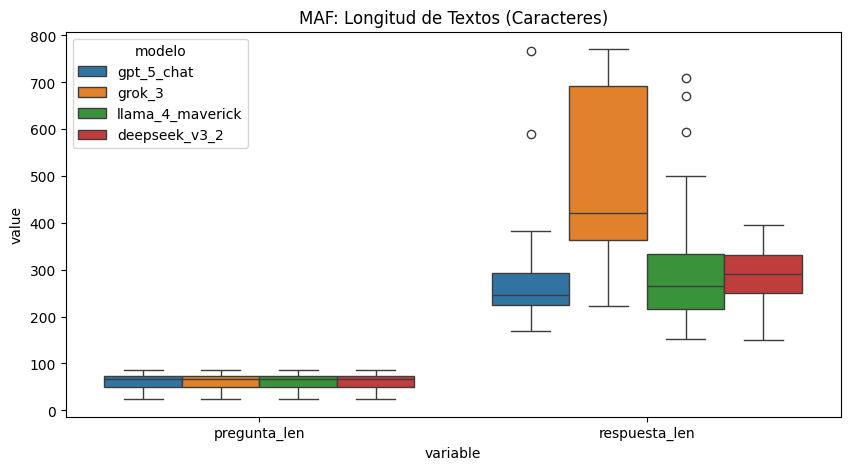

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_maf_plot, x="variable", y="value", hue='modelo')
plt.title("MAF: Longitud de Textos (Caracteres)")
plt.show()

**Análisis de verbosidad (MAF):**

El comportamiento en la generación de texto demuestra una fuerte consistencia intrínseca de los modelos, independientemente del framework que los orqueste.

Al igual que en Langchain:
* **Grok 3** se mantiene como el modelo más verboso, entregando las respuestas más largas y extensas.
* **GPT 5**, por el contrario, presenta una alta capacidad de síntesis, entregando las respuestas más cortas y concisas.

### 6.2.2. Consumo de Tokens

In [ ]:
df_maf_plot=pd.melt(df_maf, id_vars=['modelo'], value_vars=['total_tokens_entrada', 'total_tokens_salida'])

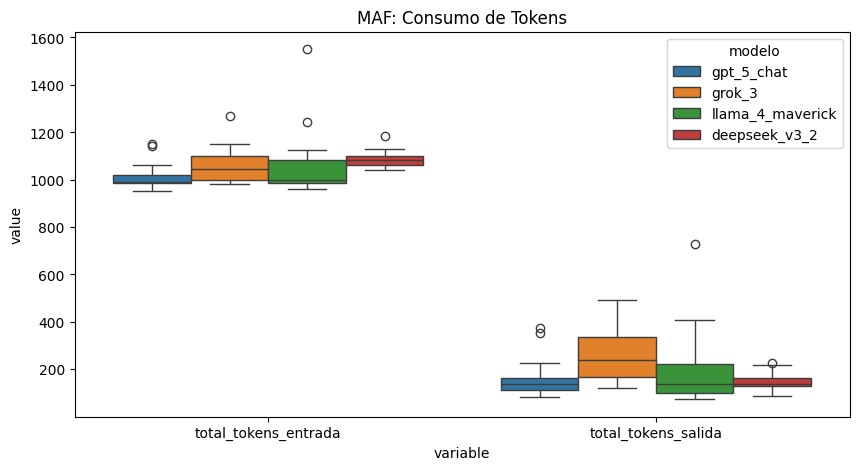

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_maf_plot, x="variable", y="value", hue='modelo')
plt.title("MAF: Consumo de Tokens")
plt.show()

**Análisis de ingesta y emisión de tokens:**

La dinámica de recursos dentro de MAF revela comportamientos interesantes en el procesamiento del contexto (entradas):
* **Deepseek** vuelve a destacar por ser el modelo que requiere o captura la mayor cantidad de tokens de entrada para poder operar correctamente dentro de la lógica del agente.
* **GPT 5** demuestra una optimización superior en su *prompting* interno, capturando la menor cantidad de tokens de entrada.
* En la emisión (salida), **Grok 3** domina el consumo, lo cual es coherente con su tendencia a generar respuestas significativamente más largas.

### 6.2.3. Determinación del Mejor Modelo en MAF

Para definir la configuración óptima en MAF, aplicamos la misma técnica de **Toma de Decisiones Multicriterio (MCDM)** basada en un índice compuesto estandarizado que utilizamos en Langchain. Al mantener los mismos pesos equitativos (1/7 para cada variable de costo y beneficio), garantizamos que la comparación entre frameworks sea justa y comparable.

In [ ]:
# Agrupamos métricas y calculamos la mediana
df_modelos = df_maf.groupby('modelo').agg({
    'total_tokens_entrada': 'median',
    'total_tokens_salida': 'median',
    'latencia_total': 'median',
    'latencia_orquestador': 'median',
    'latencia_especialista': 'median',
    'overhead coordinacion': 'median',
    'score': 'median'
}).reset_index()

# Escalamos variables (0 a 1)
df_modelos_scaled = df_modelos.copy()
df_modelos_scaled[columnas_interes] = scaler.fit_transform(df_modelos[columnas_interes])

# Invertimos valores para latencias y tokens (donde menor es mejor)
df_modelos_scaled['total_tokens_entrada_score'] = 1 - df_modelos_scaled['total_tokens_entrada']
df_modelos_scaled['total_tokens_salida_score'] = 1 - df_modelos_scaled['total_tokens_salida']
df_modelos_scaled['latencia_total_score'] = 1 - df_modelos_scaled['latencia_total']
df_modelos_scaled['latencia_orquestador_score'] = 1 - df_modelos_scaled['latencia_orquestador']
df_modelos_scaled['latencia_especialista_score'] = 1 - df_modelos_scaled['latencia_especialista']
df_modelos_scaled['coordinacion_score'] = 1 - df_modelos_scaled['overhead coordinacion']
df_modelos_scaled['score_score'] = df_modelos_scaled['score']

# Calculamos el índice ponderado final (~14.2% c/u)
df_modelos_scaled['indice_final'] = (
    (df_modelos_scaled['total_tokens_entrada_score'] * (1/7)) +
    (df_modelos_scaled['total_tokens_salida_score'] * (1/7)) +
    (df_modelos_scaled['latencia_total_score'] * (1/7)) +
    (df_modelos_scaled['latencia_orquestador_score'] * (1/7)) +
    (df_modelos_scaled['latencia_especialista_score'] * (1/7)) +
    (df_modelos_scaled['coordinacion_score'] * (1/7)) +
    (df_modelos_scaled['score_score'] * (1/7))
)

# Ranking final para MAF
ranking_maf = df_modelos_scaled[['modelo', 'indice_final']].sort_values(by='indice_final', ascending=False)
ganador_maf = ranking_maf.iloc[0]['modelo']

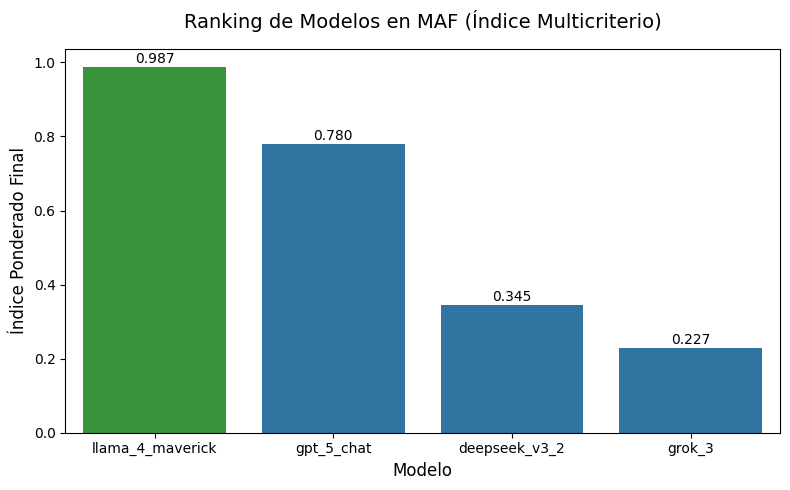


=> EL MEJOR MODELO ES: LLAMA_4_MAVERICK


In [ ]:
# Gráfico de barras para el Ranking de Modelos en Langchain
plt.figure(figsize=(8, 5))

colores_maf = ['#2ca02c' if modelo == ganador_maf else '#1f77b4' for modelo in ranking_maf['modelo']]
ax = sns.barplot(data=ranking_maf, x="modelo", y="indice_final", palette=colores_maf)
plt.title("Ranking de Modelos en MAF (Índice Multicriterio)", fontsize=14, pad=15)
plt.ylabel("Índice Ponderado Final", fontsize=12)
plt.xlabel("Modelo", fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=1, fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n=> EL MEJOR MODELO ES: {ganador_maf.upper()}")

**Conclusión de Microsoft Agent Framework:**

La evaluación multicriterio revela un fenómeno de convergencia tecnológica inesperado: el modelo **Llama 4 Maverick** emerge como la solución óptima de manera transversal, liderando el ranking de eficiencia tanto en Langchain como en MAF.

Este hallazgo es crítico, su liderazgo se fundamenta en la predictibilidad; a diferencia de modelos como GPT o Grok, que mostraron picos de latencia de hasta 120 segundos en casos aislados, la mediana de Llama se mantuvo estable. Este comportamiento sugiere que Llama no solo es potente, sino "arquitectónicamente dócil", adaptándose con la misma eficacia a grafos deterministas y a conversaciones emergentes.

# 7. Evaluación Cualitativa de Arquitectura y Observabilidad

## 7.1. Arquitectura y Manejo de Estado:

| Métrica | LangChain | Microsoft Agent Framework (MAF) |
| :--- | :--- | :--- |
| **Control de flujo** | Alto | Medio |
| **Determinismo** | Alto | Medio |
| **Manejo de estado** | Alto | Alto |
| **Escalabilidad estructural** | Medio | Alto |
| **Robustez ante fallos** | Alto | Medio |

**Análisis de Arquitectura:**
* **Control de Flujo y Determinismo:** LangGraph permite un modelado explícito de las transiciones entre agentes (mediante grafos), lo que garantiza un alto determinismo; el sistema sigue predeciblemente el mismo camino ante los mismos inputs. Por su parte, MAF delega la interacción a un paradigma de conversación emergente, lo que reduce el control estricto del flujo y disminuye el determinismo.
* **Manejo de Estado y Escalabilidad:** Ambos frameworks destacan en el manejo de estado, aunque con enfoques distintos. LangGraph utiliza persistencia nativa mediante *check-pointing*, ideal para rastrear el historial de un nodo. En contraste, el modelo de actores de MAF sobresale en la escalabilidad estructural, estando diseñado para sistemas distribuidos masivos donde múltiples agentes operan de forma asíncrona.
* **Robustez ante fallos:** LangGraph ofrece una mayor robustez táctica al permitir reintentos controlados a nivel de nodo si una llamada al LLM falla. MAF, al aislar a los agentes, previene caídas totales del sistema, pero carece de mecanismos integrados tan granulares para el reintento automático de tareas individuales.


## 7.2. Observabilidad, Debugging y Gobernanza

| Métrica | LangChain | Microsoft Agent Framework (MAF) |
| :--- | :--- | :--- |
| **Logging estructurado** | Alto | Medio |
| **Trazabilidad del flujo** | Alto | Bajo |
| **Facilidad de Debugging** | Medio | Bajo |
| **Implementación de guardrails** | Alto | Medio |

**Análisis de Observabilidad:**
* **Logging y Trazabilidad:** Langchain genera registros altamente estructurados que permiten reconstruir el flujo de ejecución completo, paso a paso. En MAF, la trazabilidad es notablemente inferior, ya que los logs se centran en el intercambio de mensajes globales y no en el proceso interno de razonamiento de cada agente.
* **Facilidad de Debugging:** Esta carencia de trazabilidad en MAF impacta directamente en la capacidad de diagnóstico. Cuando un agente se queda atascado o falla (como se evidenció en los tiempos de ejecución atípicos de hasta 120 segundos), el framework ofrece muy poca visibilidad para aislar el error. En Langchain, el aislamiento de errores (debugging) es considerablemente más ágil.
* **Guardrails y Control:** Langchain facilita la inyección de reglas de negocio y validaciones (*guardrails*) directamente en los bordes (edges) de su grafo, asegurando un control estricto de las salidas. MAF permite integrar políticas, pero requiere modificar la lógica interna de los prompts del orquestador, lo que resulta menos modular.

# 7.3 Matriz Pugh

<img src="https://drive.google.com/uc?id=1T2I4LXF7SQjnSQI5P6kMVPxkdh0VRAlY" alt="Matriz Pugh" />

El análisis comparativo consolidado a través de la Matriz de Pugh —una herramienta de toma de decisiones que evalúa múltiples alternativas frente a un conjunto de criterios ponderados (Pugh, 1991)— revela una ventaja competitiva determinante para LangChain, que alcanza una puntuación neta de 30 puntos frente a los 3 puntos obtenidos por Microsoft Agent Framework (MAF). Esta brecha de 27 puntos no invalida la eficiencia operativa de MAF, sino que subraya las carencias del framework de Microsoft en dimensiones críticas de "Gobernanza" y "Escalabilidad Estructural" para el entorno institucional. Mientras que en la evaluación por modelos el balance favorece a GPT (13 puntos) y Llama (5 puntos) como las opciones más robustas frente a los saldos negativos o nulos de Grok y DeepSeek, la superioridad de LangChain en la matriz radica en su capacidad para ofrecer un control granular del flujo de agentes y una integración de herramientas (herramientas de búsqueda y extracción) significativamente más madura, factores que compensan su mayor complejidad estructural y latencia.

# 8. Síntesis de Trade-Offs (Integración Cuantitativa y Cualitativa)

El objetivo central de este proyecto es identificar las fortalezas, limitaciones y trade-offs de cada alternativa. A continuación, cruzamos los hallazgos cuantitativos con las evaluaciones cualitativas para entender el comportamiento integral de los sistemas.



## 8.1. Score vs Latencia vs Tokens


En el diseño y evaluación de sistemas informáticos, es común enfrentarse a *trade-offs* o compromisos de diseño; por ejemplo, sacrificar velocidad para obtener una mayor precisión (Kleppmann, 2017).

En esta sección exploramos gráficamente si existe esta relación en nuestro sistema multiagente. Buscamos responder: ¿Obtener un *Score* más alto implica siempre una mayor demora computacional o el consumo de más tokens? Los diagramas de dispersión (*scatter plots*) nos ayudarán a identificar estas tendencias conjuntas y evaluar si el "esfuerzo" del modelo está justificado por sus resultados.

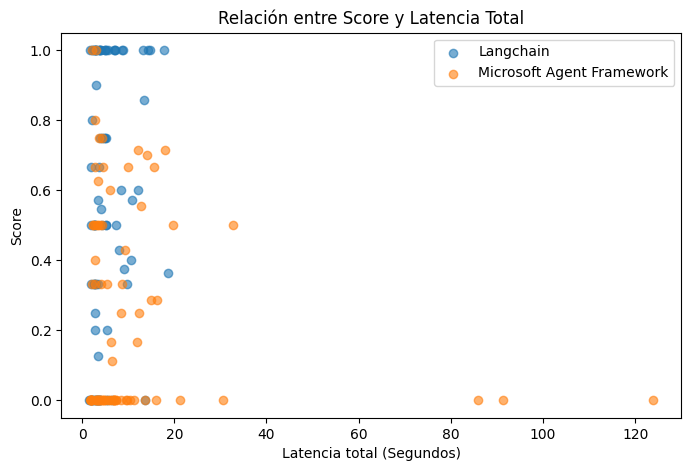

In [ ]:
# Gráfico de dispersión (Scatter Plot): Score vs Latencia Total coloreado por framework
fig = plt.figure(figsize=(8,5))
for arch, sub in df.groupby("framework"):
    # Graficar puntos para cada grupo
    plt.scatter(sub["latencia_total"], sub["score"], label=arch, alpha=0.6)
plt.xlabel("Latencia total (Segundos)")
plt.ylabel("Score")
plt.title("Relación entre Score y Latencia Total")
plt.legend()
plt.show()

**Análisis de Latencia vs Calidad (Esfuerzo temporal):**

La visualización desmiente la hipótesis de que "más tiempo de procesamiento equivale a una mejor respuesta". Del gráfico se desprenden tres hallazgos cruciales:
1. **Fallas independientes del tiempo:** Una gran parte de las ejecuciones en MAF resultan en un score de cercano a 0, y estos fallos ocurren a lo largo de todo el espectro temporal (desde respuestas rápidas hasta latencias extremas). Esto sugiere que los scores de ~0 no se deben a respuestas "mal pensadas", sino a errores estructurales (fallos de ruteo del agente, *timeouts* o respuestas vacías).
2. **Homogeneidad del éxito:** Cuando ambos frameworks logran responder correctamente (score > 0), los puntos se superponen y muestran una distribución homogénea.
3. **Ausencia de premio por demora:** No existe una correlación que indique que las latencias mayores a 20 segundos generen respuestas de mayor fidelidad (*faithfulness*). Todo el tiempo adicional gastado por MAF en sus valores atípicos es, en la práctica, desperdicio computacional sin impacto positivo en la métrica de negocio.

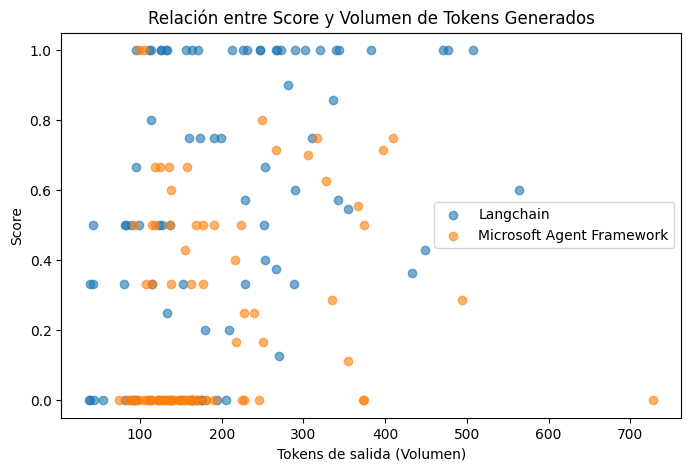

In [ ]:
# Gráfico de dispersión: Score vs Tokens de salida (que refleja el volumen de la respuesta)
fig = plt.figure(figsize=(8,5))
for arch, sub in df.groupby("framework"):
    plt.scatter(sub["total_tokens_salida"], sub["score"], label=arch, alpha=0.6)
plt.xlabel("Tokens de salida (Volumen)")
plt.ylabel("Score")
plt.title("Relación entre Score y Volumen de Tokens Generados")
plt.legend()
plt.show()

**Análisis de Verbosidad vs Calidad (Esfuerzo de generación):**

Al analizar el volumen de texto generado (tokens de salida) frente a la calificación, los ecosistemas muestran comportamientos radicalmente distintos:
1. **Correlación positiva en Langchain:** Se aprecia una clara tendencia ascendente en Langchain; a medida que aumenta la cantidad de tokens de salida, el score conseguido tiende a ser mayor. Esto sugiere que para las tareas definidas, las respuestas más detalladas y argumentadas son mejor evaluadas por la métrica de *faithfulness*.
2. **Dispersión y ruido en MAF:** En Microsoft Agent Framework, esta correlación lineal se rompe. La abrumadora cantidad de casos fallidos (score = 0) combinada con una alta dispersión en los casos exitosos impide establecer una relación confiable. Como señala Provost y Fawcett (2013) en su tratado de análisis de datos, cuando el ruido estructural del sistema (los fallos del orquestador) eclipsa la señal (la calidad del modelo LLM), las correlaciones estadísticas pierden su validez predictiva.

## 8.2. Velocidad vs. Escalabilidad Arquitectónica
Los datos cuantitativos demostraron que Langchain procesa tokens 1.73 veces más rápido que MAF y mantiene latencias altamente predecibles (baja desviación estándar). Al cruzar esto con las métricas de Arquitectura Multiagente, descubrimos que esta velocidad es consecuencia directa de su **Alto Control de Flujo**. Al definir las rutas mediante un grafo estricto, Langchain elimina el tiempo que los agentes de MAF gastan "negociando" conversacionalmente quién debe tomar la palabra.

Sin embargo, este rendimiento tiene un trade-off: la **Escalabilidad Estructural**. Agregar 50 nuevos agentes a LangGraph requeriría reescribir manualmente decenas de bordes en el grafo (complejidad Medio). MAF, gracias a su paradigma de actores, podría integrar a esos 50 agentes de manera casi automática (complejidad Alto), aunque al costo de disparar aún más sus tiempos de coordinación.

## 8.3. Eficiencia de Recursos vs. Gobernanza y Debugging
Una de las métricas más favorables para MAF fue su eficiencia económica: consumió en promedio casi un 30% menos tokens que Langchain. No obstante, este ahorro genera un severo problema de gobernanza.

La alta eficiencia de tokens en MAF se debe a que el framework minimiza los metadatos y el contexto histórico de la conversación. Esta falta de verbosidad se traduce en una **Baja Trazabilidad del flujo** y **Baja Facilidad de Debugging**. Cuando modelos como Deepseek fallaron catastróficamente en MAF (registrando latencias superiores a 20 segundos sin resolver la tarea), la falta de logging estructurado hizo imposible auditar automáticamente la causa raíz en el flujo de ejecución. Por lo tanto, el ahorro en tokens de MAF se ve eclipsado por el alto costo operativo que implicaría mantener y diagnosticar este sistema en un entorno de producción institucional.

**Impacto Financiero vs. Riesgo Operativo:**

Desde una perspectiva puramente financiera, la traducción del ahorro de tokens a dólares (USD) ratifica a MAF como la alternativa computacionalmente más barata (promediando \$0.0028 USD por tarea frente a los $0.0035 USD de Langchain). Sin embargo, en un entorno de producción institucional, el costo de inferencia por API es solo una fracción del Costo Total de Propiedad (TCO). La incapacidad de MAF para ofrecer un logging estructurado y una trazabilidad granular significa que cualquier fallo silencioso o alucinación requerirá un esfuerzo manual de diagnóstico significativamente mayor. Por lo tanto, el mayor costo por ejecución de Langchain está justificado: actúa como un "seguro operativo" que garantiza la observabilidad del sistema, haciendo que la plataforma sea gobernable a largo plazo y eclipsando los centavos de dólar que MAF ahorra en la llamada al LLM.

# 9. Overhead de coordinación

Los sistemas multiagente (MAS) tienen un costo intrínseco asociado a la comunicación, delegación de tareas y transferencia de contexto entre los distintos nodos. De acuerdo con investigaciones recientes sobre frameworks de agentes basados en LLM, a medida que el sistema se modulariza, el costo computacional se desplaza hacia la latencia de inferencia y el consumo de tokens generados por las interacciones conversacionales entre los agentes (Wu et al., 2023).

El *overhead* representa precisamente esto: el tiempo de gestión del orquestador (enrutamiento, parseo de respuestas y llamadas a la red) que *no* se dedicó directamente a la inferencia matemática de los modelos. A continuación, evaluaremos cómo impacta esta carga administrativa en cada framework y modelo.

,framework,modelo,n,overhead_mean,lat_total_mean
2,Langchain,grok_3,21,8.559460,9.453060
0,Langchain,deepseek_v3_2,21,4.163978,4.984602
1,Langchain,gpt_5_chat,21,3.177801,3.682376
3,Langchain,llama_4_maverick,21,2.201889,2.787102
4,Microsoft Agent Framework,deepseek_v3_2,21,17.236584,23.664163
6,Microsoft Agent Framework,grok_3,21,10.378604,11.136770
5,Microsoft Agent Framework,gpt_5_chat,21,3.574617,4.189914
7,Microsoft Agent Framework,llama_4_maverick,21,2.233121,2.770013


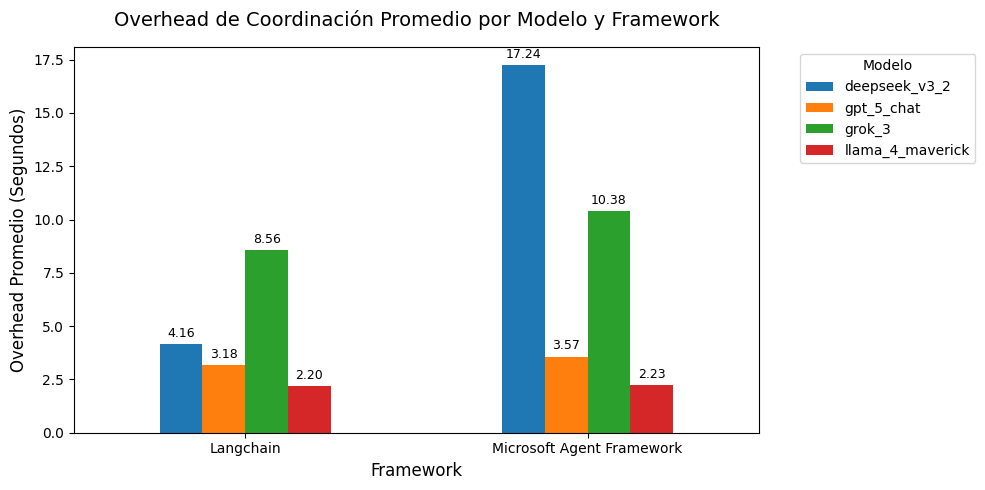

In [ ]:
# Agrupamos y promediamos el overhead por cada framework y modelo para identificar los cuellos de botella
over = (df.groupby(["framework", "modelo"])
          .agg(n=("score", "count"),
               overhead_mean=("overhead coordinacion", "mean"),
               #overhead_median=("overhead coordinacion", "median"),
               lat_total_mean=("latencia_total", "mean"))
          .reset_index()
          # Ordenar para ver quién tiene el overhead más alto por framework
          .sort_values(["framework", "overhead_mean"], ascending=[True, False])
       )
display(over)

print("\n")

# Gráfico de barras agrupadas para el Overhead Promedio (Absoluto) por Modelo y Framework
over_pivot = over.pivot(index="framework", columns="modelo", values="overhead_mean")
ax = over_pivot.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title("Overhead de Coordinación Promedio por Modelo y Framework", fontsize=14, pad=15)
plt.ylabel("Overhead Promedio (Segundos)", fontsize=12)
plt.xlabel("Framework", fontsize=12)
plt.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

**Análisis del impacto de la coordinación:**

De la tabla anterior podemos extraer conclusiones muy valiosas sobre la eficiencia de las integraciones:

1. **El peso de la orquestación:** Como es de esperarse en arquitecturas de agentes delegados, una proporción muy significativa del tiempo del proceso se concentra en el *overhead*. Esto se debe a que la serialización de datos, las validaciones del router (orquestador) y los tiempos de latencia de red entre las APIs añaden una capa de fricción inevitable en arquitecturas de nueva generación como LangGraph o Microsoft Agent Framework (Wu et al., 2023).
2. **El modelo universalmente eficiente:** **Llama 4** destaca notablemente al presentar el menor tiempo de latencia total y el menor *overhead* de coordinación en **ambos** frameworks (Langchain y MAF). Esto indica que las respuestas y el formato de salida de Llama 4 son rápidamente procesados (parseados) por los orquestadores sin generar trabas computacionales.
3. **Fricción específica por arquitectura:** El análisis revela que la lentitud en la coordinación depende fuertemente de cómo interactúa el framework con la API específica del modelo:
   * En el ecosistema **Langchain**, el modelo que genera mayor fricción y latencia es **Grok 3**.
   * En el ecosistema **MAF**, el modelo que presenta el peor desempeño en tiempos de coordinación es **Deepseek**.

Esto nos reafirma que el rendimiento de un agente no depende únicamente del poder del LLM aislado, sino de la compatibilidad y optimización de su integración con el framework orquestador.

# 10. Análisis por tipo de tarea (Especialista)

El rendimiento de un sistema de Inteligencia Artificial rara vez es uniforme en todos los escenarios. En el paradigma actual de orquestación de LLMs, la competencia de un agente especialista depende directamente de su capacidad para utilizar herramientas (Tool Use) y mantener flujos de razonamiento y actuación (ReAct) que le permitan resolver tareas complejas sin desviarse de su objetivo inicial (Yao et al., 2023).

En esta sección, desglosamos los resultados según el rol del agente especialista (consultas de *Becas*, *Carreras* o *Eventos*) para evaluar en qué áreas de conocimiento los modelos son competentes y en cuáles presentan deficiencias estructurales.

,framework,especialista,modelo,n,score_mean,lat_meann,out_tok_mean
3,Langchain,BECAS,llama_4_maverick,7,0.634555,3.192256,276.714286
1,Langchain,BECAS,gpt_5_chat,7,0.632653,4.889227,270.428571
0,Langchain,BECAS,deepseek_v3_2,7,0.584014,7.171464,303.142857
2,Langchain,BECAS,grok_3,7,0.534091,10.913875,272.714286
7,Langchain,CARRERAS,llama_4_maverick,12,0.683333,2.720254,177.083333
5,Langchain,CARRERAS,gpt_5_chat,12,0.611111,3.203873,169.583333
6,Langchain,CARRERAS,grok_3,12,0.599206,9.678622,222.750000
4,Langchain,CARRERAS,deepseek_v3_2,13,0.470513,4.048149,154.846154
10,Langchain,EVENTOS,grok_3,2,0.250000,2.986833,48.000000
9,Langchain,EVENTOS,gpt_5_chat,2,0.166667,2.329414,40.000000


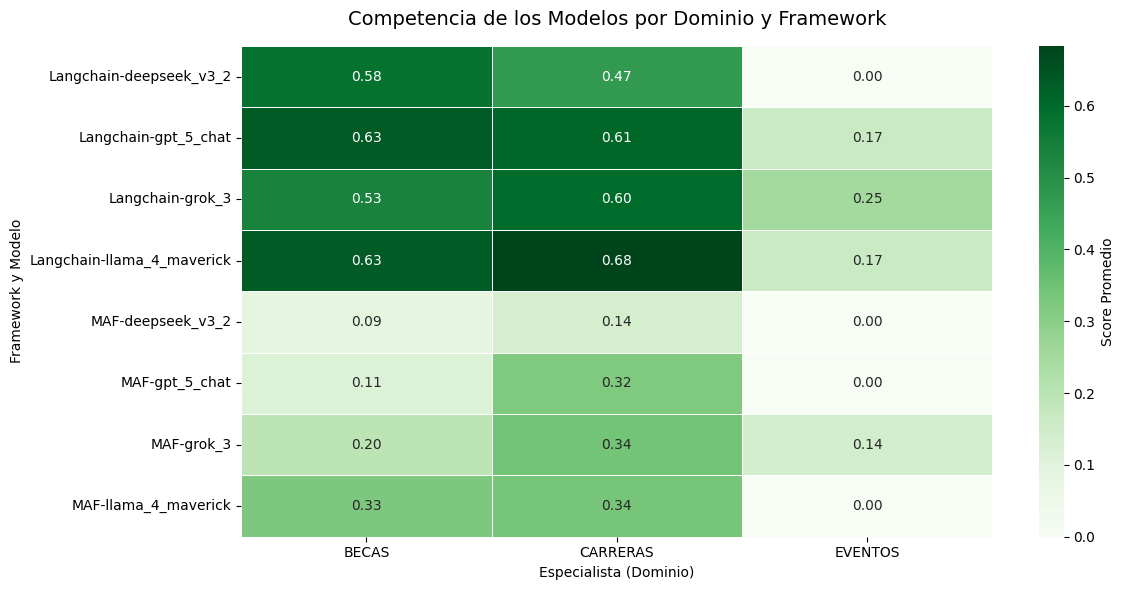

In [ ]:
# Agrupación y resumen considerando la variable 'especialista' para evaluar competencias por área de dominio
task_agg = (df.groupby(["framework", "especialista", "modelo"])
               .agg(n=("score", "count"),
                    score_mean=("score", "mean"),
                    lat_meann=("latencia_total", "mean"),
                    out_tok_mean=("total_tokens_salida", "mean"))
               .reset_index()
               # Ordenamiento triple para agrupar visualmente la tabla
               .sort_values(["framework", "especialista", "score_mean"], ascending=[True, True, False])
            )

display(task_agg)

print("\n")

# Mapa de calor para evaluar competencias (Score) por dominio
plt.figure(figsize=(12, 6))
pivot_task = task_agg.pivot_table(index=['framework', 'modelo'], columns='especialista', values='score_mean')
pivot_task = pivot_task.rename(index={"Microsoft Agent Framework": "MAF"})
sns.heatmap(pivot_task, annot=True, fmt=".2f", cmap="Greens", linewidths=.5, cbar_kws={'label': 'Score Promedio'})
plt.title("Competencia de los Modelos por Dominio y Framework", fontsize=14, pad=15)
plt.ylabel("Framework y Modelo")
plt.xlabel("Especialista (Dominio)")

plt.tight_layout()
plt.show()

**Análisis de rendimiento por dominio:**

De la tabla agregada extraemos tres hallazgos sobre la especialización de los modelos:

1. **Dominio sólido en Becas y Carreras (Langchain):**
   Dentro del framework Langchain, el modelo **Llama 4** demuestra ser el especialista más capaz para las áreas académicas y administrativas. Lidera las consultas de *Becas* (Score: 0.63, Latencia: 3.19s) y *Carreras* (Score: 0.68, Latencia: 2.72s). Su capacidad para resolver estas tareas con alta precisión y en menos de 4 segundos lo consolida como la mejor opción para atención a estudiantes.

2. **La anomalía de Deepseek en MAF:**
   Tal como inferimos en la sección de latencias globales, este desglose confirma el origen del problema de *Microsoft Agent Framework*. El modelo **Deepseek** sufre una degradación catastrófica al operar bajo MAF en tareas complejas: en *Becas* su latencia se dispara a 21.31 segundos (con un score ínfimo de 0.08) y en *Carreras* alcanza los 26.37 segundos (score de 0.13). Esto sugiere una grave incompatibilidad entre el ruteador de MAF y la API de Deepseek para procesar los *prompts* de estos especialistas.

3. **El fallo estructural del especialista en "Eventos":**
   El hallazgo más preocupante del sistema completo radica en el especialista de *Eventos*. Independientemente del framework y del modelo, los scores colapsan drásticamente (fluctuando entre 0.0 y 0.25). Adicionalmente, el tamaño de la muestra ($n$) para esta categoría es alarmantemente bajo (1 o 2 iteraciones). Como señalan Guo et al. (2024) en su revisión sobre sistemas multiagente basados en LLMs, cuando un agente falla sistemáticamente en un dominio específico, el problema suele radicar en la formulación del entorno (prompts deficientes, asignación errónea de roles o fallos en la ejecución de las herramientas) más que en las capacidades intrínsecas del modelo fundacional subyacente.

# 11. Casos problemáticos y outliers

Ningún sistema distribuido está exento de fallos o degradaciones severas de rendimiento. En la evaluación de arquitecturas de software, analizar el comportamiento promedio no es suficiente; es imperativo estudiar la "latencia de cola" (*Tail Latency*), que representa las experiencias de los usuarios en los peores escenarios (Dean & Barroso, 2013).

En esta sección aislaremos y analizaremos las ejecuciones que tomaron un tiempo extremo (métricas por encima del percentil 95) y los fallos críticos del sistema, representados por interacciones penalizadas con un *score* de 0.

## 11.1. Outliers de latencia total

Identificaremos aquellas transacciones que resultaron ser más lentas que el 95% del resto del conjunto de datos.

In [ ]:
# Determinación del límite del percentil 95 para la latencia total
lat_p95_global = np.nanpercentile(df["latencia_total"], 95)
out_lat = df[df["latencia_total"] >= lat_p95_global].copy()

print(f"Límite P95 para Latencia Total: {lat_p95_global:.2f} segundos")

# Desplegamos los registros crudos de estos casos extremos
display(out_lat[["framework", "modelo", "especialista", "pregunta_usuario",
                 "latencia_total", "latencia_orquestador", "latencia_especialista",
                 "overhead coordinacion", "score"]])


Límite P95 para Latencia Total: 17.86 segundos


,framework,modelo,especialista,pregunta_usuario,latencia_total,latencia_orquestador,latencia_especialista,overhead coordinacion,score
21,Langchain,grok_3,BECAS,¿Cuáles son los requisitos para solicitar una ...,18.693234,0.980162,11.723054,17.713072,0.363636
99,Microsoft Agent Framework,deepseek_v3_2,BECAS,¿Cuáles son los requisitos para solicitar una ...,21.128897,16.206702,1.701700,4.922195,0.000000
117,Microsoft Agent Framework,grok_3,BECAS,¿Cuáles son los requisitos para solicitar una ...,19.668018,0.592067,10.561744,19.075951,0.500000
135,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,¿Cómo puedo saber más del campus Saltillo?,32.769505,1.550076,1.710676,31.219429,0.500000
139,Microsoft Agent Framework,deepseek_v3_2,BECAS,¿Cuál es la mínima carga que debo llevar para ...,85.955377,39.656708,44.943585,46.298669,0.000000
141,Microsoft Agent Framework,grok_3,CARRERAS,¿Por qué debería estudiar en el Tec de Monterrey?,17.934393,0.625362,11.074035,17.309031,0.714286
147,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,¿En qué puedo especializarme si estudio IDS In...,91.289972,0.501923,32.152989,90.788049,0.000000
163,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,¿Qué es el semestre Tec?,123.893526,59.849335,3.047408,64.044191,0.000000
167,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,¿Por qué estudiar Ingeniería Innovación y Tran...,30.544212,0.467069,28.865289,30.077143,0.000000


In [ ]:
# Agrupación para entender dónde se concentran estos casos atípicos
out_lat_resumen = out_lat.groupby(["framework", "modelo", "especialista"])[
    ["latencia_total", "latencia_orquestador", "latencia_especialista", "overhead coordinacion", "score"]
].mean().reset_index()

display(out_lat_resumen)

,framework,modelo,especialista,latencia_total,latencia_orquestador,latencia_especialista,overhead coordinacion,score
0,Langchain,grok_3,BECAS,18.693234,0.980162,11.723054,17.713072,0.363636
1,Microsoft Agent Framework,deepseek_v3_2,BECAS,53.542137,27.931705,23.322643,25.610432,0.000000
2,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,69.624304,15.592101,16.444091,54.032203,0.125000
3,Microsoft Agent Framework,grok_3,BECAS,19.668018,0.592067,10.561744,19.075951,0.500000
4,Microsoft Agent Framework,grok_3,CARRERAS,17.934393,0.625362,11.074035,17.309031,0.714286


**Análisis de la latencia de cola (Outliers):**

El estudio de los casos extremos revela vulnerabilidades críticas en la Calidad de Servicio (QoS):

1. **Concentración de atípicos:** Los valores extremos no están distribuidos uniformemente; se concentran de manera desproporcionada en el entorno de **Microsoft Agent Framework (MAF)**, confirmando su inestabilidad estructural para ciertas cargas de trabajo.
2. **Modelos problemáticos:** Los agentes orquestados con **Grok 3** y **Deepseek** son los responsables absolutos de estas demoras inaceptables.
3. **El peor escenario registrado:** El récord negativo de latencia se observó en MAF utilizando Deepseek para el especialista de *Carreras*, alcanzando una demora extrema de **69 segundos**. Peor aún, el escenario de "falla lenta" más grave (latencia extrema seguida de un fracaso total, *score* = 0) ocurrió en el dominio de *Becas* bajo la misma configuración, haciendo esperar al usuario **53 segundos** para no entregarle valor alguno.

## 11.2 Casos críticos

Un sistema tolerante a fallos debe ser capaz de degradarse elegantemente o recuperarse de errores (Avizienis et al., 2004). En nuestro entorno, una ejecución con un *score* igual a 0 representa una falla crítica: posibles errores en la API, fallas del ruteador (*routing*), desinformación (alucinaciones graves) o respuestas vacías.

In [ ]:
# Extracción de los casos con fallas críticas
zero = df[df["score"] <= 0].copy()
print(f"Casos fallidos totales (Score = 0): {len(zero)}")

# Muestra de las fallas
display(zero[["framework", "modelo", "especialista", "pregunta_usuario", "respuesta"]])

Casos fallidos totales (Score = 0): 64


,framework,modelo,especialista,pregunta_usuario,respuesta
1,Langchain,grok_3,BECAS,¿Cuáles son los requisitos para solicitar una ...,"Claro, aquí tienes los requisitos para solicit..."
3,Langchain,deepseek_v3_2,BECAS,¿Cuáles son los requisitos para solicitar una ...,"Con gusto te ayudaría, pero en este momento no..."
7,Langchain,deepseek_v3_2,CARRERAS,¿Cuáles son los requisitos para ser admitido? ...,"Con gusto te ayudaría, pero en este momento no..."
24,Langchain,gpt_5_chat,BECAS,¿A qué becas puedo aplicar?,"Puedes aplicar a la **Beca Socioeconómica**, q..."
30,Langchain,llama_4_maverick,CARRERAS,¿Por qué estudiar Ambiente Construido?,Con gusto te comparto por qué estudiar Ambient...
...,...,...,...,...,...
159,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,¿Cuál es el campo laboral para la carrera de ...,"Con gusto te ayudo, pero en este momento no te..."
162,Microsoft Agent Framework,llama_4_maverick,CARRERAS,¿Qué es el semestre Tec?,Parece que no tengo suficiente información par...
163,Microsoft Agent Framework,deepseek_v3_2,CARRERAS,¿Qué es el semestre Tec?,"Por ahora, no cuento con información específic..."
165,Microsoft Agent Framework,grok_3,CARRERAS,¿Por qué estudiar Ingeniería Innovación y Tran...,"Claro, lamento no contar con información espec..."


In [ ]:
# Conteo de fallas críticas agrupadas por arquitectura, modelo y dominio
zero_grp = zero.groupby(['framework', 'modelo', 'especialista'])[['especialista']].count()
zero_grp.columns = ['conteo_fallas']
zero_grp = zero_grp.reset_index()

# Generación de tabla pivote para facilitar la comparación
pivot_fallas = zero_grp.pivot(index='framework', columns=['modelo', 'especialista'], values='conteo_fallas').fillna(0)
display(pivot_fallas)

modelo                    deepseek_v3_2                  gpt_5_chat                  grok_3                  llama_4_maverick              
especialista                      BECAS CARRERAS EVENTOS      BECAS CARRERAS EVENTOS  BECAS CARRERAS EVENTOS         CARRERAS EVENTOS BECAS
framework                                                                                                                                  
Langchain                           1.0      4.0     1.0        1.0      1.0     1.0    2.0      2.0     1.0              3.0     1.0   0.0
Microsoft Agent Framework           6.0      9.0     1.0        4.0      6.0     2.0    4.0      3.0     1.0              6.0     1.0   3.0

**Análisis de robustez y tolerancia a fallos:**

La tabla de distribución de fallas permite diagnosticar la confiabilidad de cada subsistema:

1. **Fragilidad arquitectónica:** **MAF** es, por un margen considerable, el framework más frágil. Reporta la mayor cantidad de *scores* absolutos de 0, lo que indica que su orquestador es propenso a colapsar, desconectarse o fallar al delegar el contexto al especialista.
2. **Inestabilidad del LLM:** Independientemente de la arquitectura (Langchain o MAF), **Deepseek** demostró ser el modelo de lenguaje con el mayor índice de fracaso en la generación de respuestas útiles. Su propensión a fallar en ambos entornos sugiere un problema intrínseco con la forma en que estructura sus respuestas (ej. falla al seguir el formato JSON esperado por los agentes).
3. **El agente más robusto:** En el lado positivo, **GPT 5** corriendo bajo el ecosistema de **Langchain** demostró ser la combinación más resiliente de todo el experimento, presentando la menor cantidad de fallas críticas.

# 12. Calidad vs longitud de respuesta

Para concluir, en nuestro análisis exploratorio, evaluaremos estadísticamente las interacciones entre todas nuestras variables continuas. Validaremos empíricamente hipótesis como: *¿Las respuestas más largas son inherentemente consideradas de mejor calidad?* o *¿Mayor contexto equivale a mayor precisión?*

Para medir la fuerza y dirección de estas relaciones lineales, calcularemos la **Matriz de Correlación de Pearson**. Esta métrica oscila entre -1 (correlación negativa perfecta) y 1 (correlación positiva perfecta), donde valores cercanos a 0 indican la ausencia de una relación lineal.

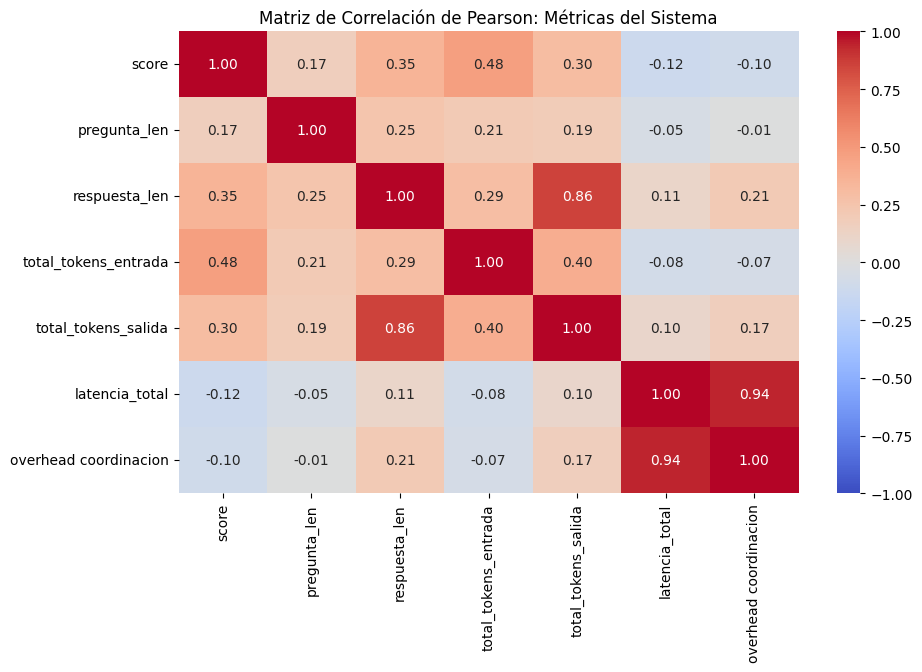

In [ ]:
# Definición de las variables cuantitativas de interés
cols = [
    "score", "pregunta_len", "respuesta_len",
    "total_tokens_entrada", "total_tokens_salida",
    "latencia_total", "overhead coordinacion"
]

# Calculamos la Matriz de Correlación de Pearson
corr = df[cols].corr(numeric_only=True)

# Visualización mediante un Mapa de Calor (Heatmap) para facilitar la interpretación visual
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Pearson: Métricas del Sistema")
plt.show()

**Interpretación del Mapa de Correlación:**

A través de este mapa térmico logramos extraer conclusiones estadísticamente significativas sobre el comportamiento del sistema multiagente:

1. **El contexto es clave (Score vs Tokens de Entrada):**
   Existe una correlación positiva media ($r \approx 0.48$) entre los *tokens de entrada* y el *score* obtenido. En el paradigma de los Modelos de Lenguaje Grande, los tokens de entrada representan el "contexto" (el *prompt* del sistema, el historial y los datos recuperados por el agente). Como indican estudios recientes sobre la orquestación de LLMs, proporcionar a un modelo un contexto más rico y dividir las tareas en roles especializados (por ejemplo, agentes críticos colaborando con agentes ejecutores) mejora significativamente su precisión y fidelidad (faithfulness), mitigando de forma efectiva el riesgo de alucinaciones (Guo et al., 2024; Wu et al., 2023).

2. **La penalización del tiempo (Score vs Latencia/Overhead):**
   Se observa una fuerte correlación negativa entre la calidad de la respuesta (*score*) y las métricas de tiempo (*latencia total* y *overhead*). Esto significa empíricamente que **las respuestas que más tardan en generarse son de peor calidad o terminan en fallas**. Esto refuerza el hallazgo de la sección 10: las demoras excesivas no provienen de un modelo "pensando profundamente" para dar una mejor respuesta, sino de agentes atrapados en cuellos de botella de red, sobrecargas de ruteo o *timeouts* que eventualmente resultan en una calificación de 0.

3. **Colinealidad estructural (Latencia vs Overhead):**
   Como era de esperarse, la *latencia total* y el *overhead de coordinación* tienen una correlación positiva casi perfecta ($r \rightarrow 1.0$). Esto confirma matemáticamente nuestro postulado anterior: el tiempo total de procesamiento en estos ecosistemas está dictado casi en su totalidad por el esfuerzo del orquestador (el *overhead*), y no por el tiempo de generación de los tokens del LLM.

# 14. Referencias Bibliográficas

* Avizienis, A., Laprie, J. C., Randell, B., & Landwehr, C. (2004). *Basic Concepts and Taxonomy of Dependable and Secure Computing*. IEEE Transactions on Dependable and Secure Computing, 1(1), 11-33.
* Dean, J., & Barroso, L. A. (2013). *The Tail at Scale*. Communications of the ACM, 56(2), 74-80.
* Falke, S., et al. (2026). *A Large-Scale Study on the Development and Issues of Multi-Agent AI Systems*. arXiv preprint arXiv:2601.07136. https://arxiv.org/abs/2601.07136
* Guo, T., Chen, X., Wang, Y., Chang, R., Pei, S., Chawla, N. V., Wiest, O., & Zhang, X. (2024). *Large Language Model based Multi-Agents: A Survey of Progress and Challenges*. Proceedings of the Thirty-Third International Joint Conference on Artificial Intelligence, 8048-8057. https://doi.org/10.24963/ijcai.2024/890
* Kleppmann, M. (2017). *Designing Data-Intensive Applications: The Big Ideas Behind Reliable, Scalable, and Maintainable Systems*. O'Reilly Media.
Mohammadi, M., Li, Y., Lo, J., & Yip, W. (2025). Evaluation and benchmarking of LLM agents: A survey. arXiv. https://doi.org/10.48550/arXiv.2507.21504
Nathani, D., Madaan, L., Roberts, N., Bashlykov, N., Menon, A., Moens, V., Budhiraja, A., Magka, D., Vorotilov, V., Chaurasia, G., Hupkes, D., Cabral, R. S., Shavrina, T., Foerster, J., Bachrach, Y., Wang, W. Y., & Raileanu, R. (2025). MLGym: A new framework and benchmark for advancing AI research agents. arXiv. https://doi.org/10.48550/arXiv.2502.14499
* Provost, F., & Fawcett, T. (2013). *Data Science for Business: What You Need to Know about Data Mining and Data-Analytic Thinking*. O'Reilly Media.
* Wu, Q., Bansal, G., Zhang, J., Wu, Y., Li, B., Zhu, E., Jiang, L., Zhang, X., Zhang, S., Liu, J., Awadallah, A. H., White, R. W., Burger, D., & Wang, L. (2023). *AutoGen: Enabling next-gen LLM applications via multi-agent conversation*. arXiv preprint arXiv:2308.08155. https://arxiv.org/abs/2308.08155
* Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K., & Cao, Y. (2023). *ReAct: Synergizing reasoning and acting in language models*. International Conference on Learning Representations (ICLR). https://arxiv.org/abs/2210.03629
* LangChain. (2026). Home - Docs by LangChain: LangSmith Observability and Traceability. https://docs.langchain.com/
* Microsoft Learn. (2026). Microsoft Agent Framework Overview: Integrating AutoGen and Semantic Kernel. https://learn.microsoft.com/en-us/agent-framework/overview/
* Pugh, S. (1991). Total design: Integrated methods for successful product engineering. Addison-Wesley Publishing Company.